# Indian E-Commerce Sales & Customer Behavior Analytics
### Author: Subhadip Dutta
### Dataset: Indian E-Commerce Customer Behavior & Purchase

---

## Project Overview
This notebook performs end-to-end data analytics on an Indian E-Commerce dataset containing **25,000 customer sessions**.  
It covers:
- **Data Loading & Cleaning**
- **Exploratory Data Analysis (EDA)**
- **Customer Behavior Analysis**
- **Sales & Revenue Analysis**
- **Product & Category Analysis**
- **Marketing Channel Analysis**
- **Cart Abandonment Analysis**
- **Cohort & Seasonal Analysis**
- **Machine Learning — Purchase Prediction**
- **Interactive Dashboard (Plotly)**

---
## 1. Import Libraries

In [1]:
# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data Handling ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation (Static) ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Visualisation (Interactive) ───────────────────────────────────────────────
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, accuracy_score
)
from sklearn.pipeline import Pipeline

# ── Display Settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 35)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


---
## 2. Load & Inspect the Dataset

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('Ecommerce.csv')

print(f'Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\n── Column Names ──')
print(df.columns.tolist())
df.head(5)

Shape  : 25,000 rows × 29 columns

── Column Names ──
['customer_id', 'session_id', 'visit_date', 'device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'revenue', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased', 'cart_abandoned', 'rating', 'review_text', 'review_helpful_votes', 'payment_method', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'revenue_normalized', 'location']


,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,discount_percent,discount_amount,revenue,pages_viewed,time_on_site_sec,added_to_cart,purchased,cart_abandoned,rating,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,20,130.31,0.00,21,965,1,0,1,4,1,0,1,28,11,3,0,Long,0.00,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,15,567.16,0.00,21,1158,0,0,0,4,1,0,2,25,9,2,0,Long,0.00,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,0,0.00,0.00,19,710,1,0,1,4,1,0,2,31,5,4,1,Short,0.00,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,5,126.85,2410.23,19,1674,1,1,0,4,10,4,1,30,1,1,3,Very Long,0.31,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,0,0.00,0.00,13,427,1,0,1,4,1,0,1,25,2,6,3,Very Short,0.00,118


In [3]:
# ── Data Types & Memory ───────────────────────────────────────────────────────
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  str    
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec         25000 no

In [4]:
# ── Statistical Summary ───────────────────────────────────────────────────────
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
customer_id,25000.000000,5479.930600,2593.544596,1000.000000,3234.000000,5482.000000,7715.000000,9998.000000
session_id,25000.000000,12499.500000,7217.022701,0.000000,6249.750000,12499.500000,18749.250000,24999.000000
device_type,25000.000000,0.705040,0.639543,0.000000,0.000000,1.000000,1.000000,2.000000
user_type,25000.000000,0.551280,0.497373,0.000000,0.000000,1.000000,1.000000,1.000000
marketing_channel,25000.000000,2.514040,1.704934,0.000000,1.000000,2.000000,4.000000,5.000000
product_id,25000.000000,449.107000,259.513787,0.000000,225.000000,448.000000,675.000000,898.000000
product_category,25000.000000,3.495240,2.285053,0.000000,2.000000,4.000000,5.000000,7.000000
unit_price,25000.000000,782.319010,476.612168,50.050000,395.222500,691.725000,1096.842500,1999.830000
quantity,25000.000000,2.489040,1.114563,1.000000,1.000000,2.000000,3.000000,4.000000
discount_percent,25000.000000,8.998800,9.263640,0.000000,0.000000,10.000000,15.000000,30.000000


In [5]:
# ── Missing Values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if missing_df.empty:
    print('✅ No missing values found in the dataset.')
else:
    display(missing_df)

# ── Duplicates ────────────────────────────────────────────────────────────────
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')

✅ No missing values found in the dataset.
Duplicate rows: 0


---
## 3. Data Cleaning & Feature Engineering

In [6]:
# ── Parse Dates ───────────────────────────────────────────────────────────────
df['visit_date'] = pd.to_datetime(df['visit_date'], format='%d-%m-%Y')

# ── Decode Categorical Codes ──────────────────────────────────────────────────
device_map   = {0: 'Desktop', 1: 'Mobile', 2: 'Tablet'}
user_map     = {0: 'New User',    1: 'Returning User'}
mkt_map      = {0: 'Organic Search', 1: 'Email', 2: 'Social Media',
                3: 'Referral',        4: 'Paid Search', 5: 'Direct'}
cat_map      = {0: 'Electronics', 1: 'Fashion', 2: 'Home & Kitchen',
                3: 'Sports',       4: 'Books',   5: 'Beauty',
                6: 'Toys',         7: 'Grocery'}
pay_map      = {0: 'UPI', 1: 'Credit Card', 2: 'Debit Card',
                3: 'Net Banking', 4: 'Cash on Delivery', 5: 'Wallet'}
season_map   = {0: 'Winter', 1: 'Spring', 2: 'Summer', 3: 'Autumn'}
weekday_map  = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday',
                3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
month_map    = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

df['device_label']    = df['device_type'].map(device_map)
df['user_label']      = df['user_type'].map(user_map)
df['channel_label']   = df['marketing_channel'].map(mkt_map)
df['category_label']  = df['product_category'].map(cat_map)
df['payment_label']   = df['payment_method'].map(pay_map)
df['season_label']    = df['visit_season'].map(season_map)
df['weekday_label']   = df['visit_weekday'].map(weekday_map)
df['month_label']     = df['visit_month'].map(month_map)

# ── Derived Features ──────────────────────────────────────────────────────────
df['total_spend']       = df['unit_price'] * df['quantity'] - df['discount_amount']
df['has_discount']      = (df['discount_percent'] > 0).astype(int)
df['time_on_site_min']  = (df['time_on_site_sec'] / 60).round(2)
df['revenue_positive']  = df['revenue'] > 0

print('✅ Feature engineering complete.')
df[['device_label','user_label','channel_label','category_label',
    'payment_label','season_label','total_spend','has_discount']].head(3)

✅ Feature engineering complete.


,device_label,user_label,channel_label,category_label,payment_label,season_label,total_spend,has_discount
0,Tablet,Returning User,Social Media,Toys,Credit Card,Winter,521.26,1
1,Tablet,New User,Paid Search,Home & Kitchen,Debit Card,Winter,3213.92,1
2,Mobile,Returning User,Organic Search,Electronics,Debit Card,Spring,1601.76,0


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution — Purchased vs Not Purchased

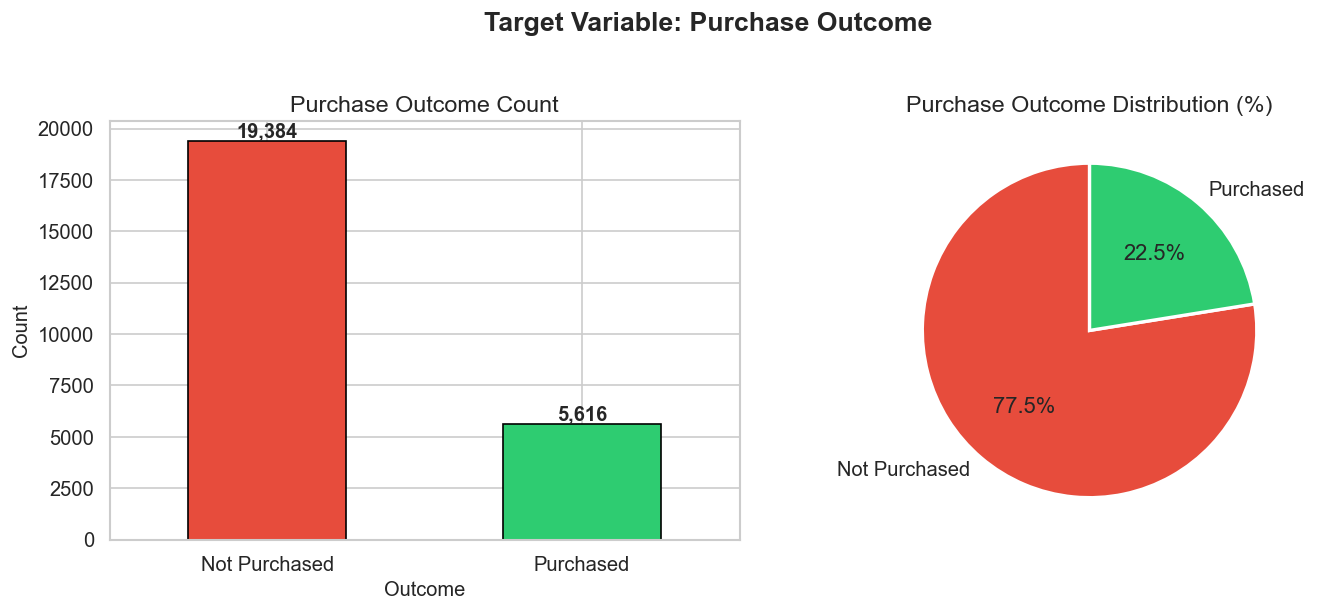

purchased
Not Purchased    19384
Purchased         5616
Name: count, dtype: int64


In [7]:
purchase_counts = df['purchased'].value_counts().rename({0: 'Not Purchased', 1: 'Purchased'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar
colors = ['#e74c3c', '#2ecc71']
purchase_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Purchase Outcome Count')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie
axes[1].pie(purchase_counts, labels=purchase_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Purchase Outcome Distribution (%)')

plt.suptitle('Target Variable: Purchase Outcome', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(purchase_counts)

### 4.2 Numerical Feature Distributions

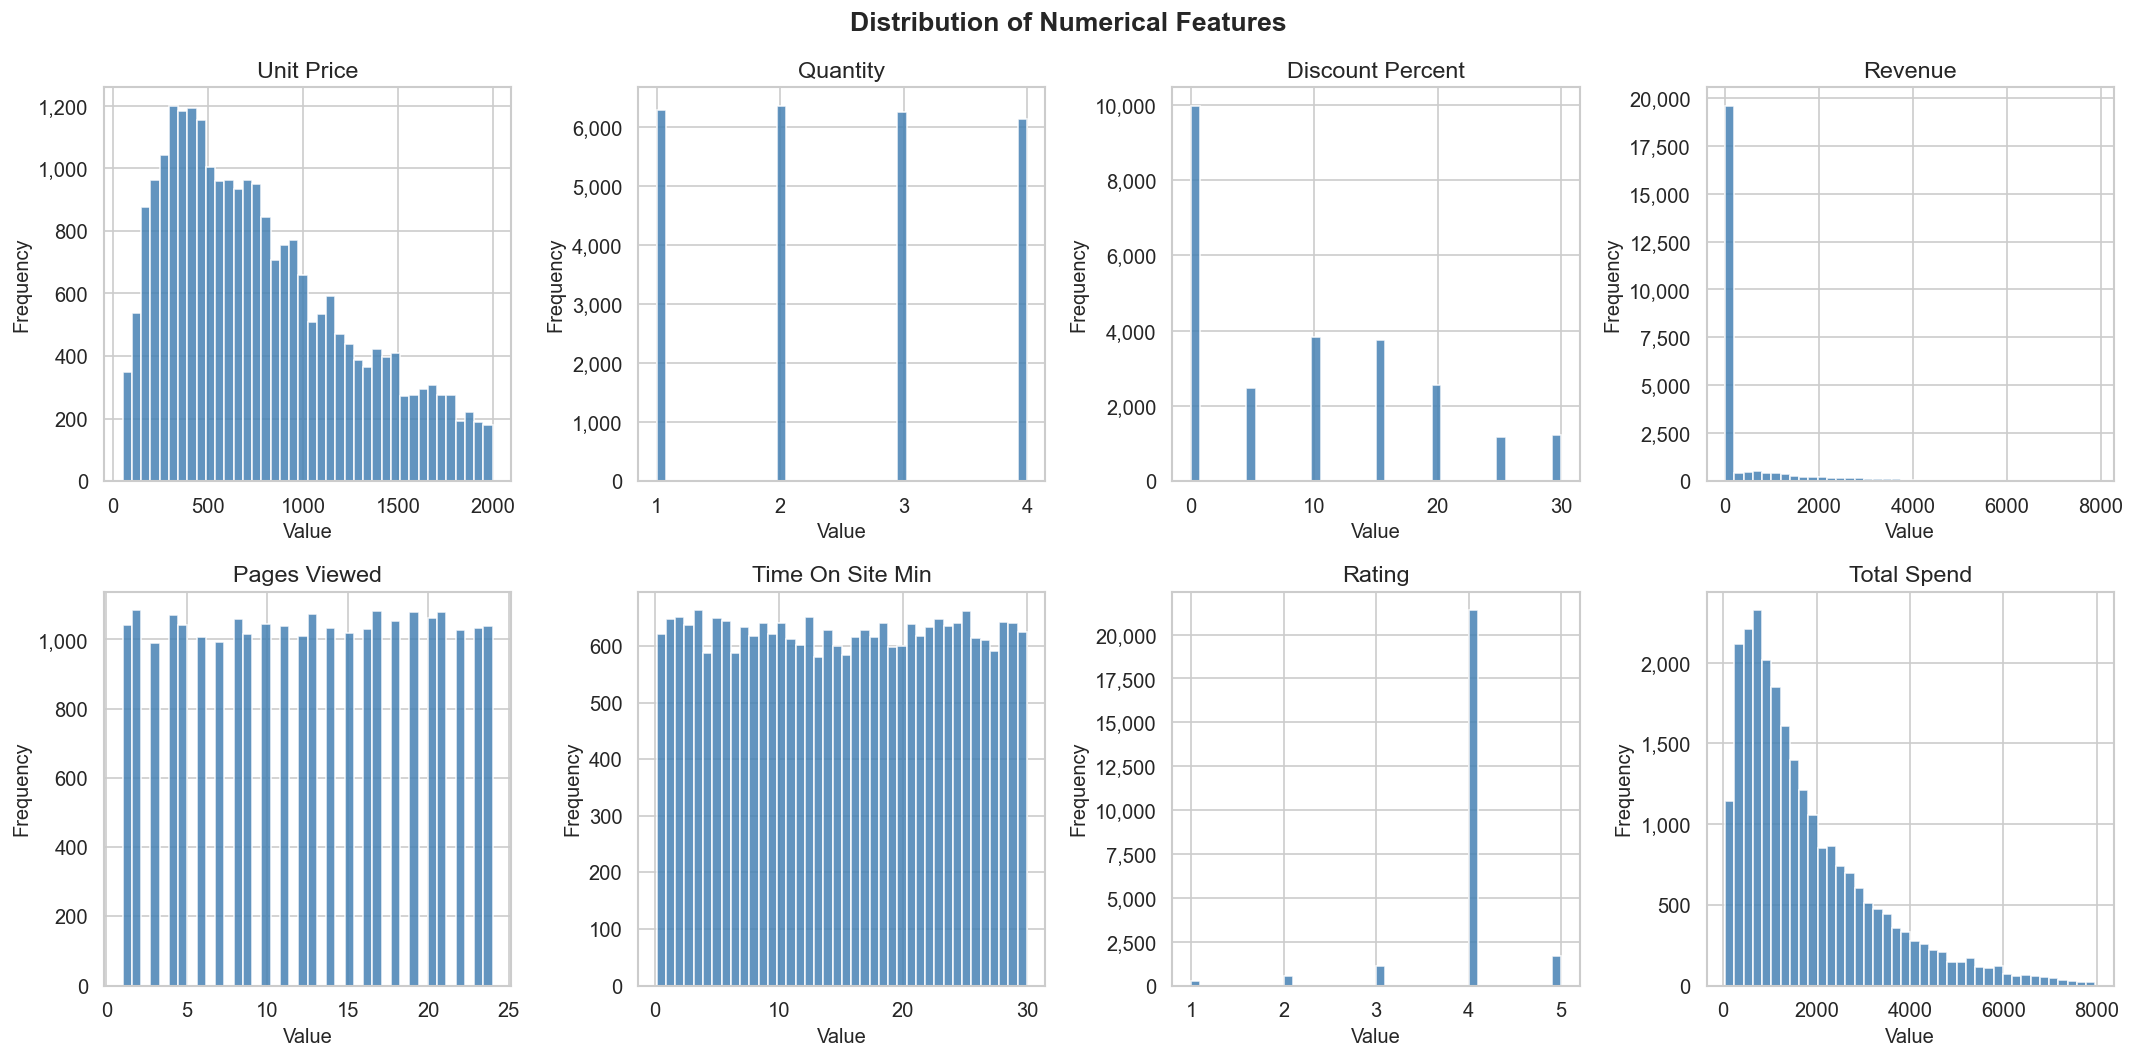

In [8]:
num_cols = ['unit_price', 'quantity', 'discount_percent', 'revenue',
            'pages_viewed', 'time_on_site_min', 'rating', 'total_spend']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Correlation Heatmap

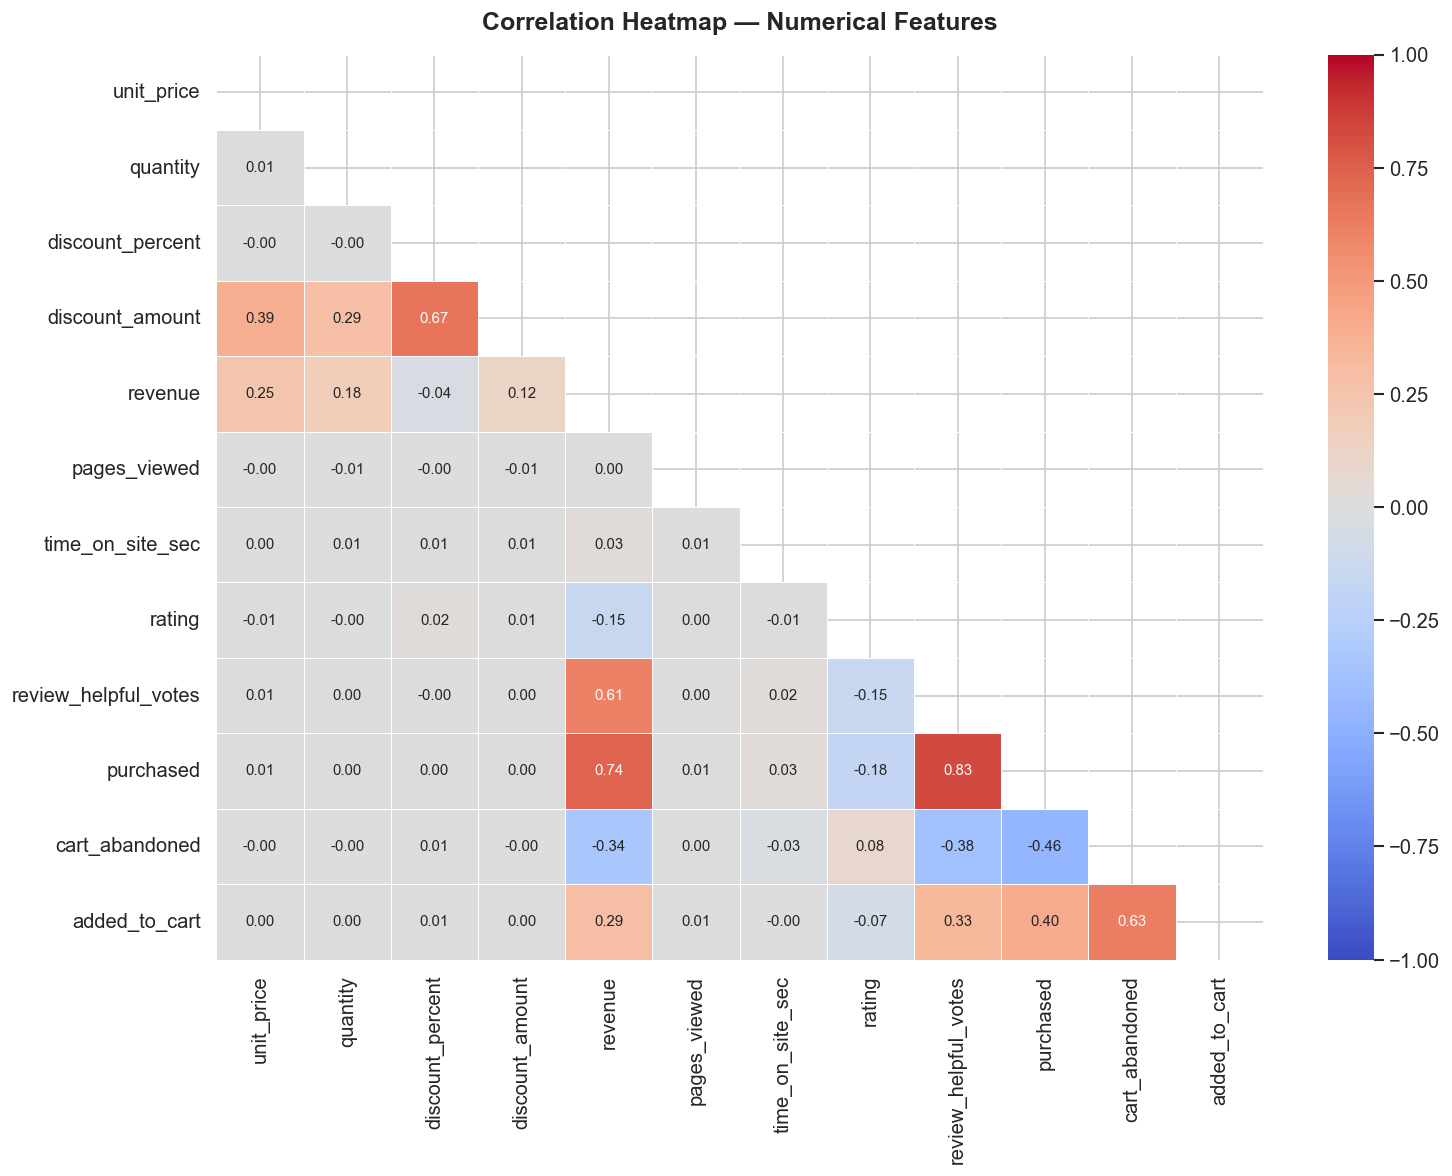

In [9]:
corr_cols = ['unit_price','quantity','discount_percent','discount_amount',
             'revenue','pages_viewed','time_on_site_sec','rating',
             'review_helpful_votes','purchased','cart_abandoned','added_to_cart']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 5. Customer Behavior Analysis

### 5.1 Device Type Usage

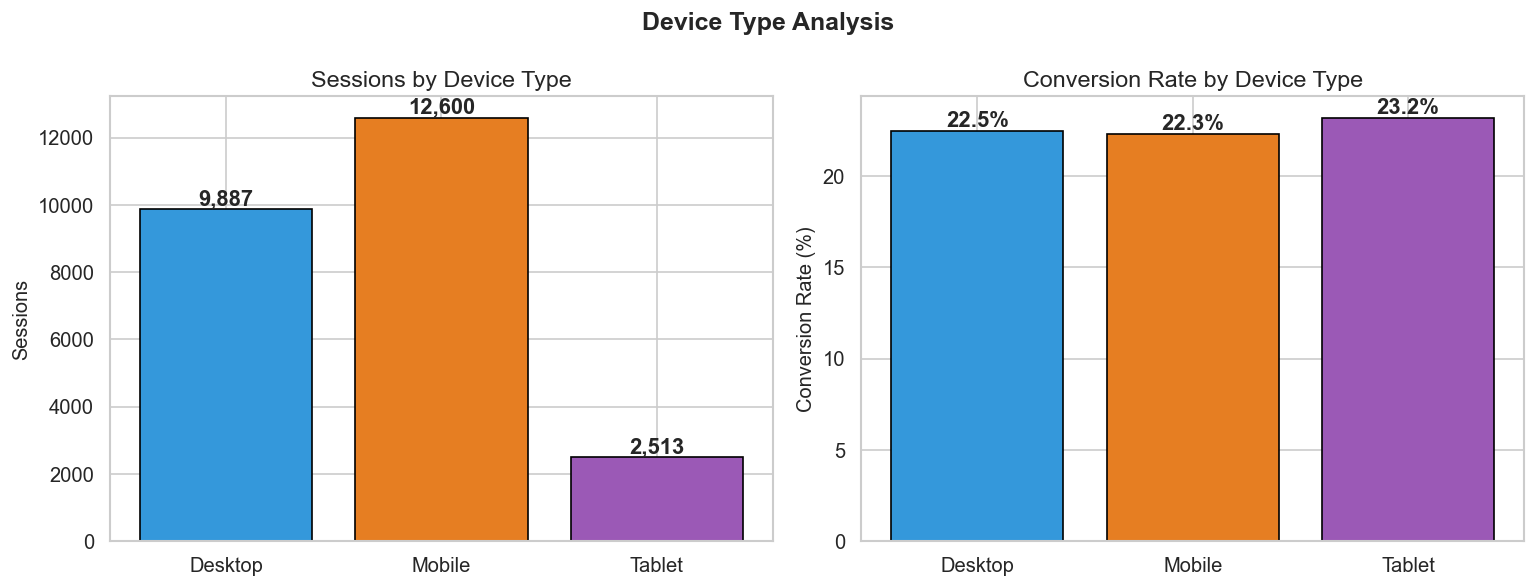

,Device,Purchases,Total Sessions,Conversion Rate (%)
0,Desktop,2221,9887,22.46
1,Mobile,2812,12600,22.32
2,Tablet,583,2513,23.20


In [10]:
device_purchase = df.groupby('device_label')['purchased'].agg(['sum','count']).reset_index()
device_purchase.columns = ['Device','Purchases','Total Sessions']
device_purchase['Conversion Rate (%)'] = (device_purchase['Purchases'] / device_purchase['Total Sessions'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

palette = ['#3498db','#e67e22','#9b59b6']
axes[0].bar(device_purchase['Device'], device_purchase['Total Sessions'],
            color=palette, edgecolor='black')
axes[0].set_title('Sessions by Device Type')
axes[0].set_ylabel('Sessions')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

axes[1].bar(device_purchase['Device'], device_purchase['Conversion Rate (%)'],
            color=palette, edgecolor='black')
axes[1].set_title('Conversion Rate by Device Type')
axes[1].set_ylabel('Conversion Rate (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.suptitle('Device Type Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
display(device_purchase)

### 5.2 New vs Returning Users

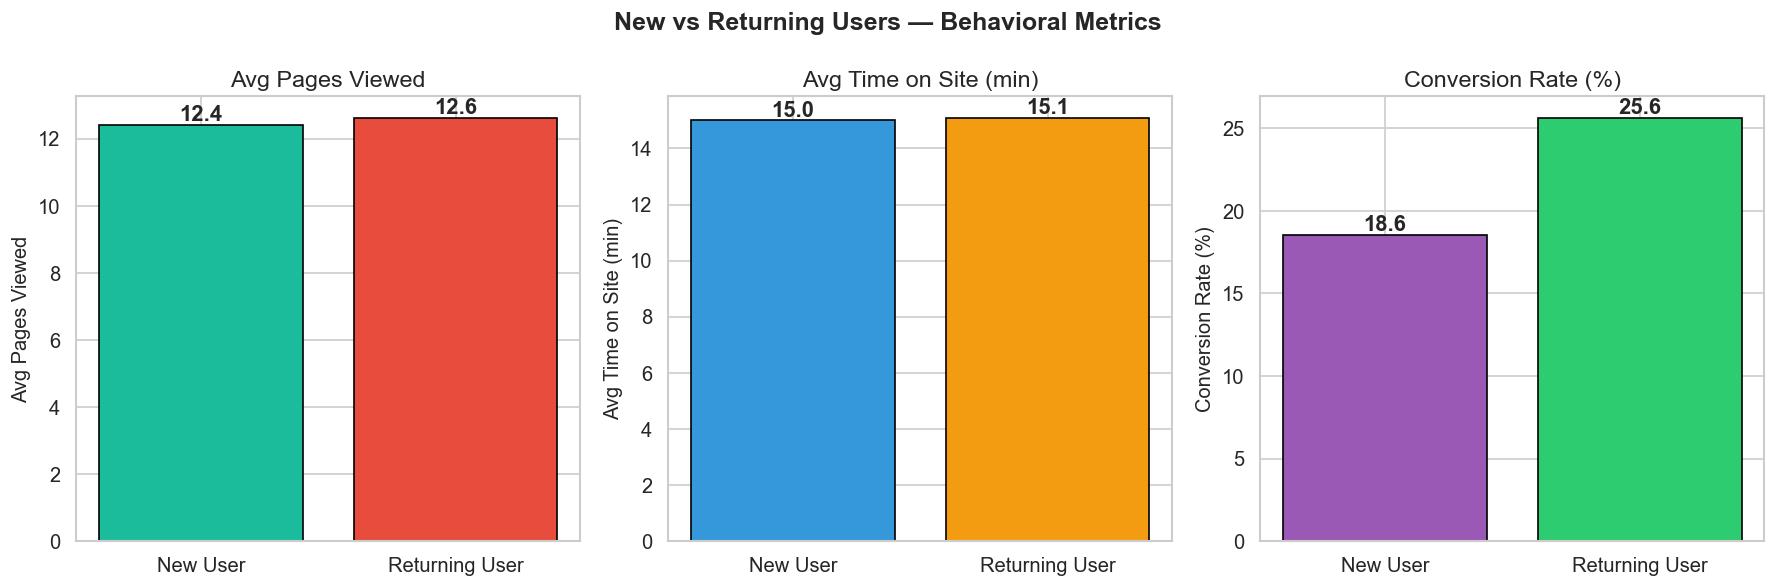

,user_label,Sessions,Avg_Pages,Avg_Time_Min,Avg_Revenue,Conversion_Rate
0,New User,11218,12.42,15.00,338.94,18.55
1,Returning User,13782,12.63,15.10,458.13,25.65


In [11]:
user_stats = df.groupby('user_label').agg(
    Sessions=('session_id','count'),
    Avg_Pages=('pages_viewed','mean'),
    Avg_Time_Min=('time_on_site_min','mean'),
    Avg_Revenue=('revenue','mean'),
    Conversion_Rate=('purchased','mean')
).reset_index()
user_stats['Conversion_Rate'] = (user_stats['Conversion_Rate'] * 100).round(2)
user_stats = user_stats.round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Avg_Pages', 'Avg_Time_Min', 'Conversion_Rate']
titles  = ['Avg Pages Viewed', 'Avg Time on Site (min)', 'Conversion Rate (%)']
colors  = [['#1abc9c','#e74c3c'], ['#3498db','#f39c12'], ['#9b59b6','#2ecc71']]

for ax, metric, title, pal in zip(axes, metrics, titles, colors):
    ax.bar(user_stats['user_label'], user_stats[metric], color=pal, edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel(title)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontweight='bold')

plt.suptitle('New vs Returning Users — Behavioral Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
display(user_stats)

### 5.3 Session Duration Bucket Analysis

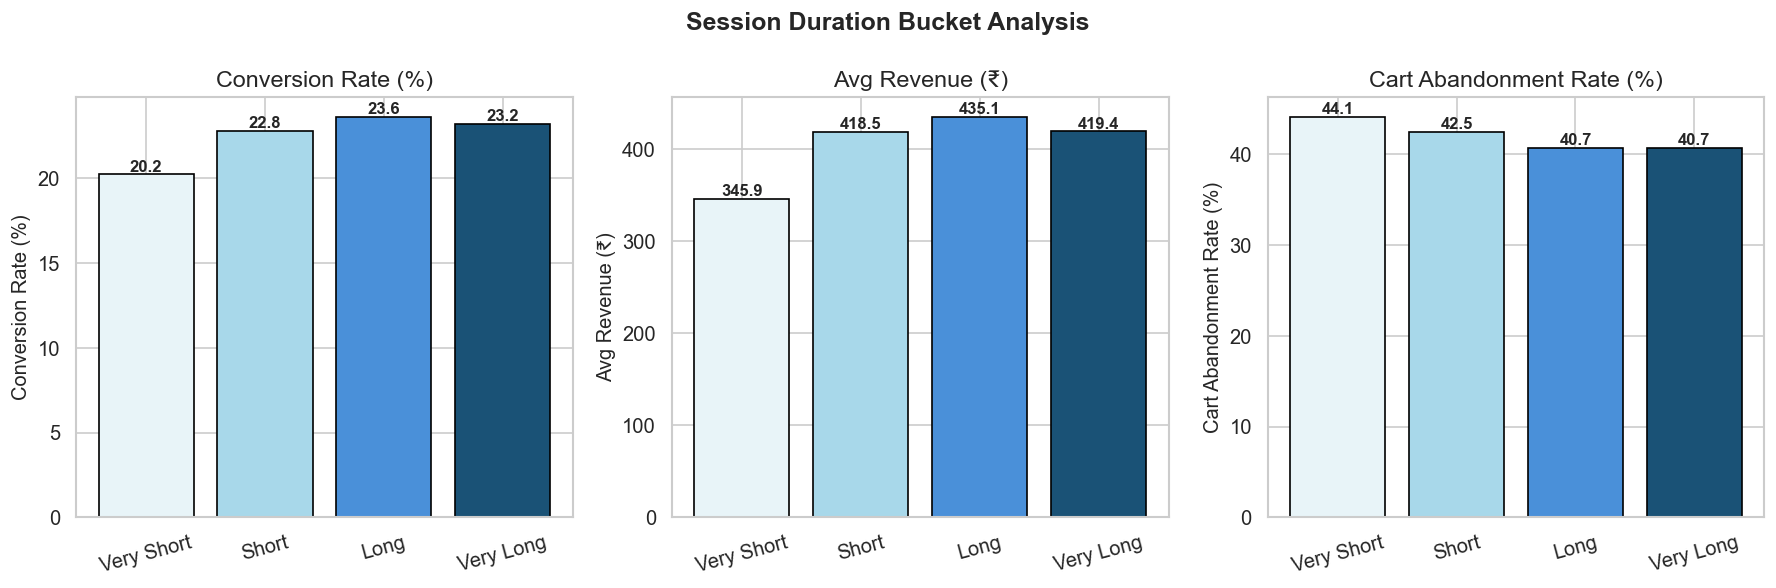

,session_duration_bucket,Sessions,Conversion_Rate,Avg_Revenue,Cart_Abandon_Rate
0,Very Short,6270,20.24,345.85,44.13
1,Short,6236,22.79,418.52,42.45
2,Long,6254,23.62,435.06,40.71
3,Very Long,6240,23.22,419.38,40.72


In [12]:
bucket_order = ['Very Short', 'Short', 'Long', 'Very Long']
bucket_stats = df.groupby('session_duration_bucket').agg(
    Sessions=('session_id','count'),
    Conversion_Rate=('purchased','mean'),
    Avg_Revenue=('revenue','mean'),
    Cart_Abandon_Rate=('cart_abandoned','mean')
).reindex(bucket_order).reset_index()
bucket_stats[['Conversion_Rate','Cart_Abandon_Rate']] = (bucket_stats[['Conversion_Rate','Cart_Abandon_Rate']] * 100).round(2)
bucket_stats['Avg_Revenue'] = bucket_stats['Avg_Revenue'].round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pal = ['#e8f4f8','#a8d8ea','#4a90d9','#1a5276']

for ax, col, title in zip(axes,
    ['Conversion_Rate','Avg_Revenue','Cart_Abandon_Rate'],
    ['Conversion Rate (%)','Avg Revenue (₹)','Cart Abandonment Rate (%)']):
    bars = ax.bar(bucket_stats['session_duration_bucket'], bucket_stats[col], color=pal, edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=15)
    for p in bars:
        ax.annotate(f'{p.get_height():.1f}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Session Duration Bucket Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
display(bucket_stats)

---
## 6. Sales & Revenue Analysis

### 6.1 Monthly Revenue Trend

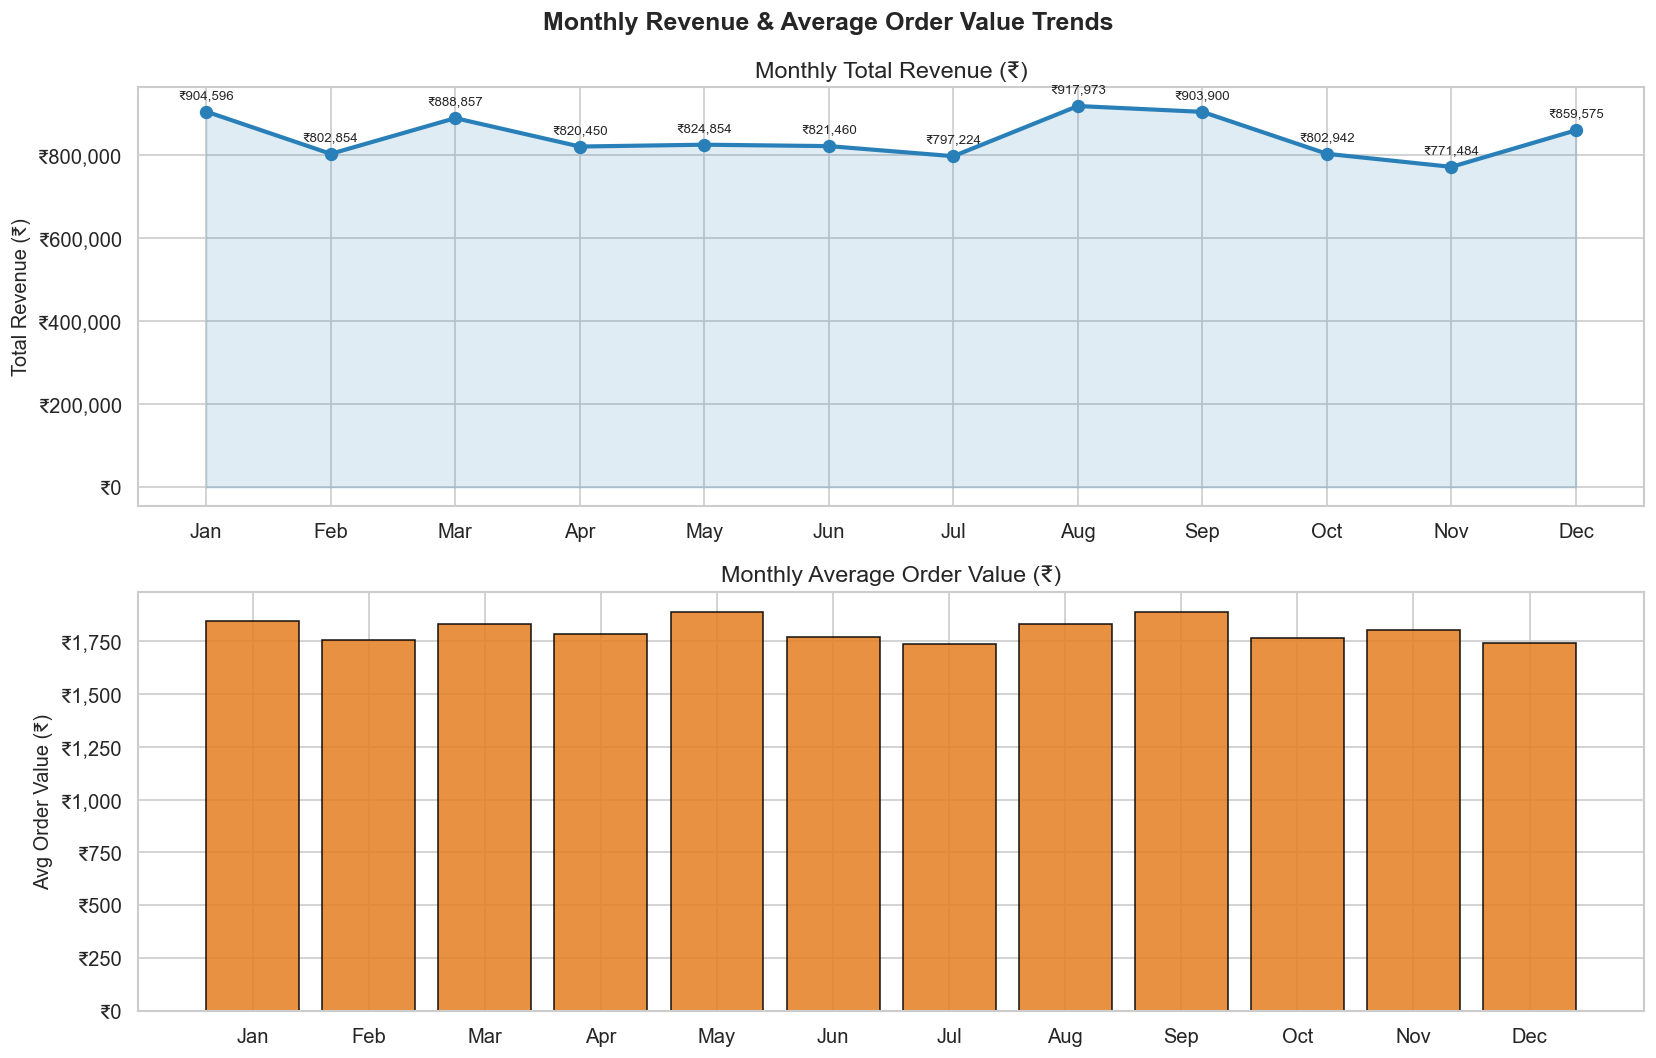

In [13]:
monthly_rev = df[df['revenue'] > 0].groupby('visit_month').agg(
    Total_Revenue=('revenue','sum'),
    Transactions=('purchased','sum'),
    Avg_Order_Value=('revenue','mean')
).reset_index()
monthly_rev['month_name'] = monthly_rev['visit_month'].map(month_map)
monthly_rev = monthly_rev.sort_values('visit_month')

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Revenue trend
axes[0].plot(monthly_rev['month_name'], monthly_rev['Total_Revenue'],
             marker='o', linewidth=2.5, color='#2980b9', markersize=7)
axes[0].fill_between(monthly_rev['month_name'], monthly_rev['Total_Revenue'],
                     alpha=0.15, color='#2980b9')
axes[0].set_title('Monthly Total Revenue (₹)')
axes[0].set_ylabel('Total Revenue (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for x, y in zip(monthly_rev['month_name'], monthly_rev['Total_Revenue']):
    axes[0].annotate(f'₹{y:,.0f}', (x, y), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

# AOV trend
axes[1].bar(monthly_rev['month_name'], monthly_rev['Avg_Order_Value'],
            color='#e67e22', edgecolor='black', alpha=0.85)
axes[1].set_title('Monthly Average Order Value (₹)')
axes[1].set_ylabel('Avg Order Value (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.suptitle('Monthly Revenue & Average Order Value Trends', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Revenue by Season

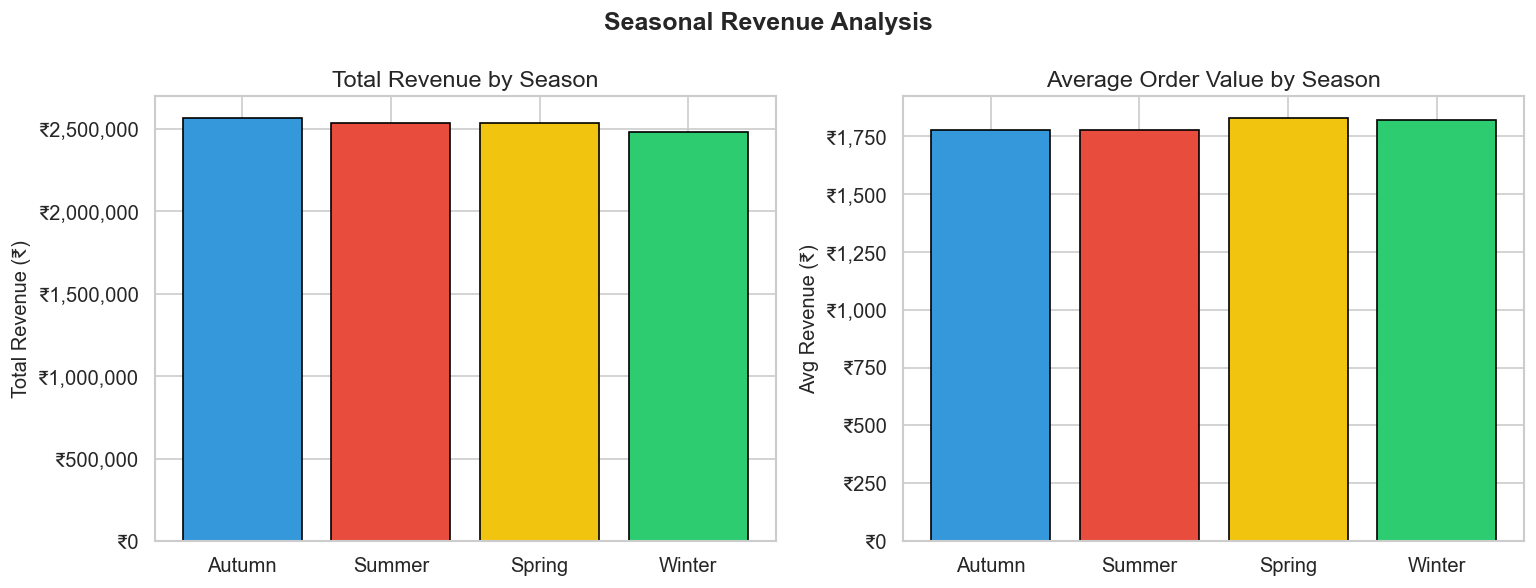

,season_label,Total_Revenue,Sessions,Avg_Revenue
0,Autumn,2567025.39,1443,1778.95
2,Summer,2536656.73,1427,1777.62
1,Spring,2534160.27,1384,1831.04
3,Winter,2478326.67,1362,1819.62


In [14]:
season_rev = df[df['revenue'] > 0].groupby('season_label').agg(
    Total_Revenue=('revenue','sum'),
    Sessions=('session_id','count'),
    Avg_Revenue=('revenue','mean')
).reset_index().sort_values('Total_Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
season_colors = ['#3498db','#e74c3c','#f1c40f','#2ecc71']

axes[0].bar(season_rev['season_label'], season_rev['Total_Revenue'],
            color=season_colors[:len(season_rev)], edgecolor='black')
axes[0].set_title('Total Revenue by Season')
axes[0].set_ylabel('Total Revenue (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

axes[1].bar(season_rev['season_label'], season_rev['Avg_Revenue'],
            color=season_colors[:len(season_rev)], edgecolor='black')
axes[1].set_title('Average Order Value by Season')
axes[1].set_ylabel('Avg Revenue (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.suptitle('Seasonal Revenue Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
display(season_rev.round(2))

### 6.3 Revenue by Day of Week

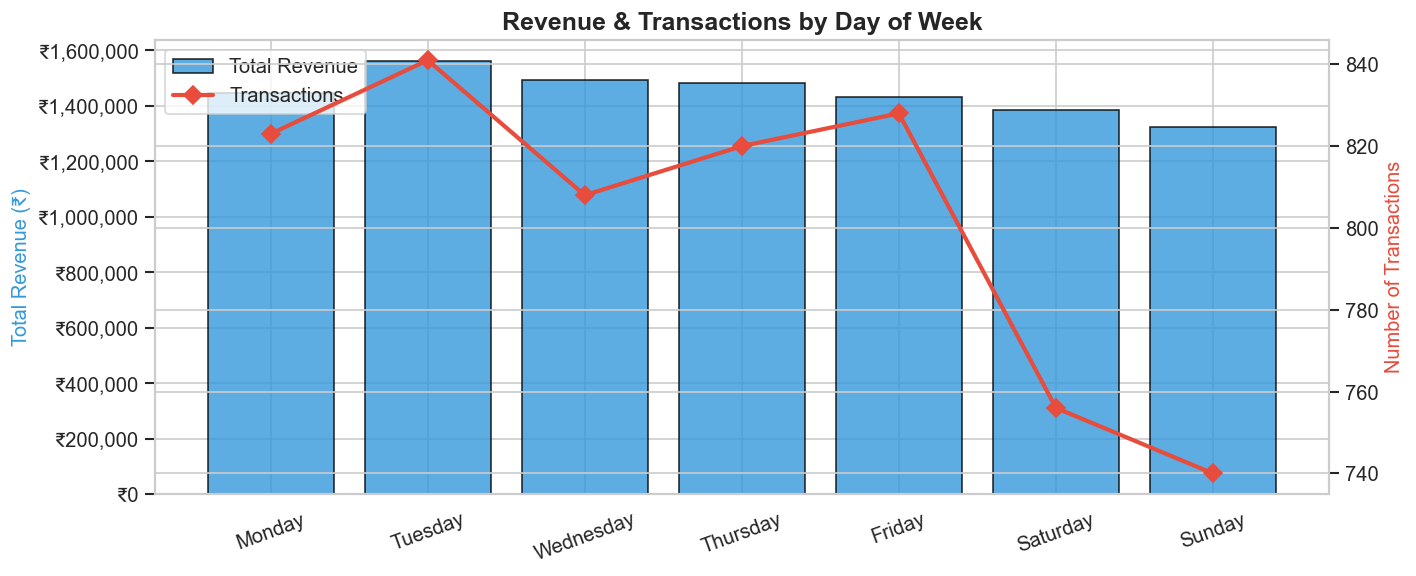

In [15]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev = df[df['revenue']>0].groupby('weekday_label')['revenue'].agg(['sum','mean','count']).reindex(dow_order).reset_index()
dow_rev.columns = ['Weekday','Total_Revenue','Avg_Revenue','Transactions']

fig, ax1 = plt.subplots(figsize=(12, 5))
bars = ax1.bar(dow_rev['Weekday'], dow_rev['Total_Revenue'],
               color='#3498db', alpha=0.8, edgecolor='black', label='Total Revenue')
ax1.set_ylabel('Total Revenue (₹)', color='#3498db')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax1.tick_params(axis='x', rotation=20)

ax2 = ax1.twinx()
ax2.plot(dow_rev['Weekday'], dow_rev['Transactions'], marker='D',
         color='#e74c3c', linewidth=2.5, markersize=8, label='Transactions')
ax2.set_ylabel('Number of Transactions', color='#e74c3c')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('Revenue & Transactions by Day of Week', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Product & Category Analysis

### 7.1 Revenue by Product Category

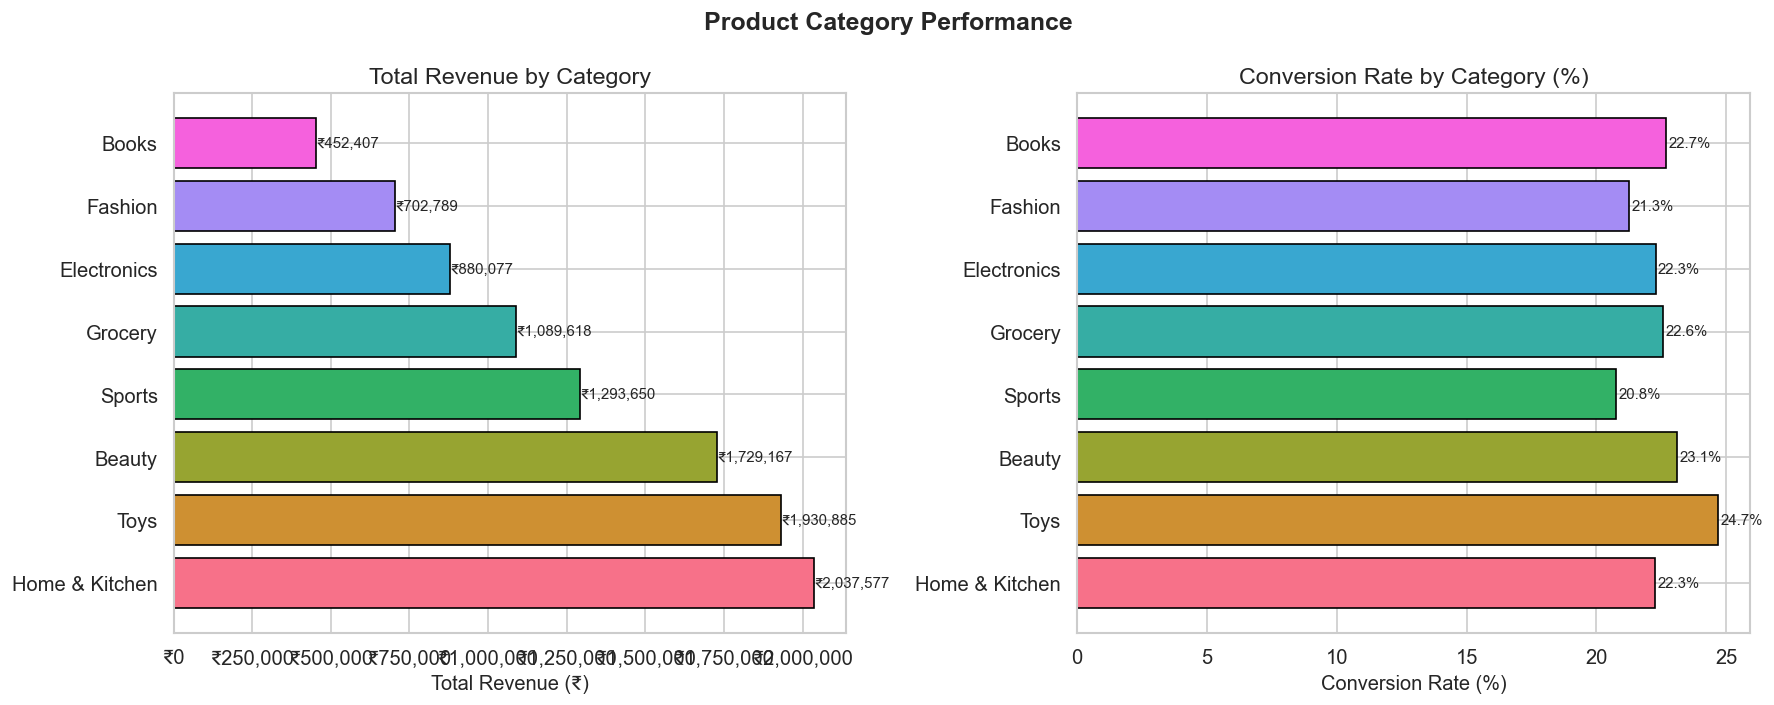

,category_label,Total_Revenue,Sessions,Purchases,Avg_Unit_Price,Avg_Rating,Conversion_Rate
5,Home & Kitchen,2037576.79,3237,721,1238.58,3.94,22.27
7,Toys,1930885.22,3112,768,1131.58,3.93,24.68
0,Beauty,1729167.16,3149,728,997.96,3.94,23.12
6,Sports,1293649.90,3040,631,898.41,3.95,20.76
4,Grocery,1089617.52,3073,694,671.48,3.95,22.58
2,Electronics,880077.03,3142,700,579.68,3.96,22.28
3,Fashion,702788.87,3043,647,455.72,3.96,21.26
1,Books,452406.57,3204,727,275.25,3.96,22.69


In [16]:
cat_stats = df.groupby('category_label').agg(
    Total_Revenue=('revenue','sum'),
    Sessions=('session_id','count'),
    Purchases=('purchased','sum'),
    Avg_Unit_Price=('unit_price','mean'),
    Avg_Rating=('rating','mean')
).reset_index()
cat_stats['Conversion_Rate'] = (cat_stats['Purchases'] / cat_stats['Sessions'] * 100).round(2)
cat_stats = cat_stats.sort_values('Total_Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Horizontal Revenue Bar
colors = sns.color_palette('husl', len(cat_stats))
axes[0].barh(cat_stats['category_label'], cat_stats['Total_Revenue'],
             color=colors, edgecolor='black')
axes[0].set_title('Total Revenue by Category')
axes[0].set_xlabel('Total Revenue (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for i, v in enumerate(cat_stats['Total_Revenue']):
    axes[0].text(v + 1000, i, f'₹{v:,.0f}', va='center', fontsize=9)

# Conversion Rate
axes[1].barh(cat_stats['category_label'], cat_stats['Conversion_Rate'],
             color=colors, edgecolor='black')
axes[1].set_title('Conversion Rate by Category (%)')
axes[1].set_xlabel('Conversion Rate (%)')
for i, v in enumerate(cat_stats['Conversion_Rate']):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Product Category Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
display(cat_stats.round(2))

### 7.2 Price vs Revenue Scatter (by Category)

In [17]:
purchased_df = df[df['revenue'] > 0].sample(n=min(3000, len(df[df['revenue']>0])), random_state=42)

fig = px.scatter(
    purchased_df, x='unit_price', y='revenue',
    color='category_label', size='quantity',
    hover_data=['discount_percent','payment_label','device_label'],
    title='Unit Price vs Revenue by Product Category',
    labels={'unit_price':'Unit Price (₹)','revenue':'Revenue (₹)','category_label':'Category'},
    template='plotly_white', opacity=0.7
)
fig.update_layout(height=500, legend_title_text='Category')
fig.show()

---
## 8. Marketing Channel Analysis

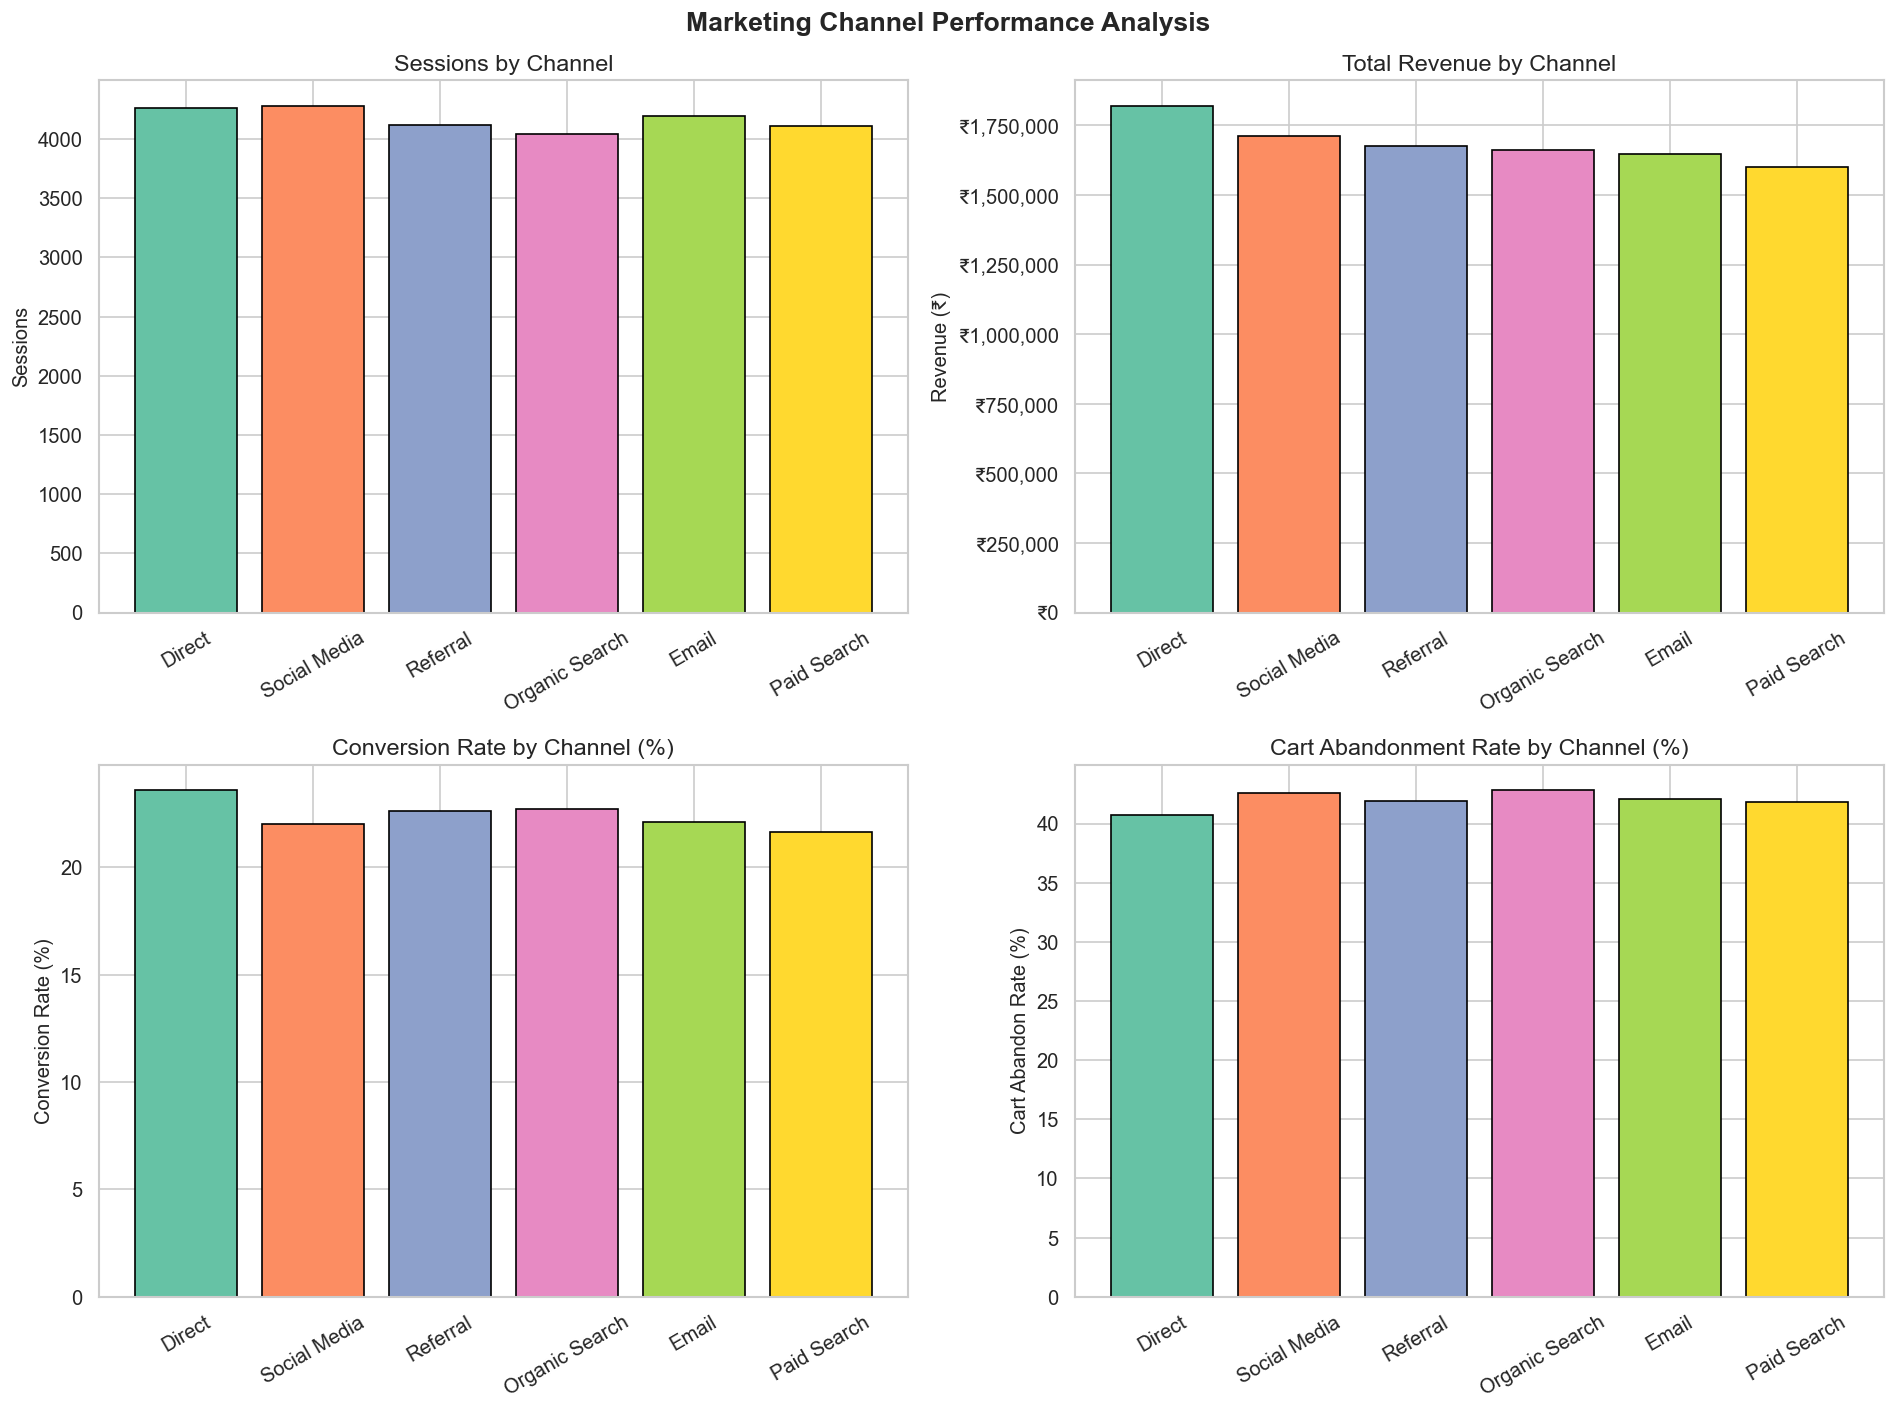

,channel_label,Sessions,Purchases,Conversion_Rate,Total_Revenue,Cart_Abandon_Rate
0,Direct,4263,1006,23.60,1820823.79,40.75
5,Social Media,4281,943,22.03,1711962.69,42.61
4,Referral,4116,932,22.64,1675463.47,41.91
2,Organic Search,4041,918,22.72,1661328.76,42.84
1,Email,4190,927,22.12,1646768.68,42.10
3,Paid Search,4109,890,21.66,1599821.67,41.86


In [18]:
channel_stats = df.groupby('channel_label').agg(
    Sessions=('session_id','count'),
    Purchases=('purchased','sum'),
    Total_Revenue=('revenue','sum'),
    Avg_Revenue=('revenue','mean'),
    Avg_Pages=('pages_viewed','mean'),
    Cart_Abandon=('cart_abandoned','mean')
).reset_index()
channel_stats['Conversion_Rate'] = (channel_stats['Purchases'] / channel_stats['Sessions'] * 100).round(2)
channel_stats['Cart_Abandon_Rate'] = (channel_stats['Cart_Abandon'] * 100).round(2)
channel_stats = channel_stats.sort_values('Total_Revenue', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

pal = sns.color_palette('Set2', len(channel_stats))

# Sessions
axes[0,0].bar(channel_stats['channel_label'], channel_stats['Sessions'], color=pal, edgecolor='black')
axes[0,0].set_title('Sessions by Channel')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].set_ylabel('Sessions')

# Revenue
axes[0,1].bar(channel_stats['channel_label'], channel_stats['Total_Revenue'], color=pal, edgecolor='black')
axes[0,1].set_title('Total Revenue by Channel')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].set_ylabel('Revenue (₹)')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

# Conversion Rate
axes[1,0].bar(channel_stats['channel_label'], channel_stats['Conversion_Rate'], color=pal, edgecolor='black')
axes[1,0].set_title('Conversion Rate by Channel (%)')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].set_ylabel('Conversion Rate (%)')

# Cart Abandonment
axes[1,1].bar(channel_stats['channel_label'], channel_stats['Cart_Abandon_Rate'], color=pal, edgecolor='black')
axes[1,1].set_title('Cart Abandonment Rate by Channel (%)')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].set_ylabel('Cart Abandon Rate (%)')

plt.suptitle('Marketing Channel Performance Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
display(channel_stats[['channel_label','Sessions','Purchases','Conversion_Rate','Total_Revenue','Cart_Abandon_Rate']].round(2))

---
## 9. Cart Abandonment & Discount Analysis

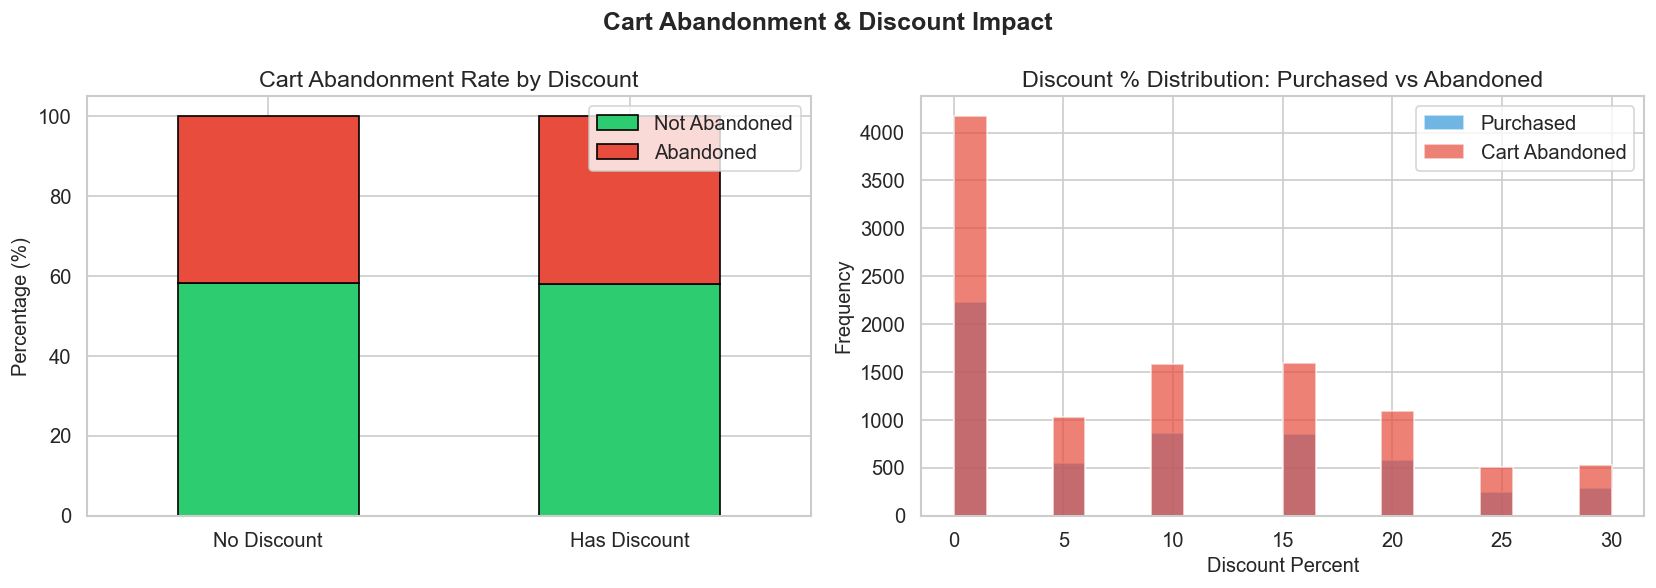

In [19]:
# Cart abandonment vs discount
cart_disc = df.groupby(['has_discount','cart_abandoned']).size().reset_index(name='Count')
cart_disc['Discount'] = cart_disc['has_discount'].map({0:'No Discount',1:'Has Discount'})
cart_disc['Cart Status'] = cart_disc['cart_abandoned'].map({0:'Not Abandoned',1:'Abandoned'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar — discount vs cart abandonment
pivot = df.groupby('has_discount')['cart_abandoned'].value_counts(normalize=True).unstack()*100
pivot.index = ['No Discount','Has Discount']
pivot.columns = ['Not Abandoned','Abandoned']
pivot.plot(kind='bar', stacked=True, ax=axes[0],
           color=['#2ecc71','#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Cart Abandonment Rate by Discount')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(loc='upper right')

# Discount % distribution for purchased vs abandoned
df[df['purchased']==1]['discount_percent'].plot(kind='hist', bins=20,
    ax=axes[1], alpha=0.7, color='#3498db', label='Purchased')
df[df['cart_abandoned']==1]['discount_percent'].plot(kind='hist', bins=20,
    ax=axes[1], alpha=0.7, color='#e74c3c', label='Cart Abandoned')
axes[1].set_title('Discount % Distribution: Purchased vs Abandoned')
axes[1].set_xlabel('Discount Percent')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Cart Abandonment & Discount Impact', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Payment Method Analysis

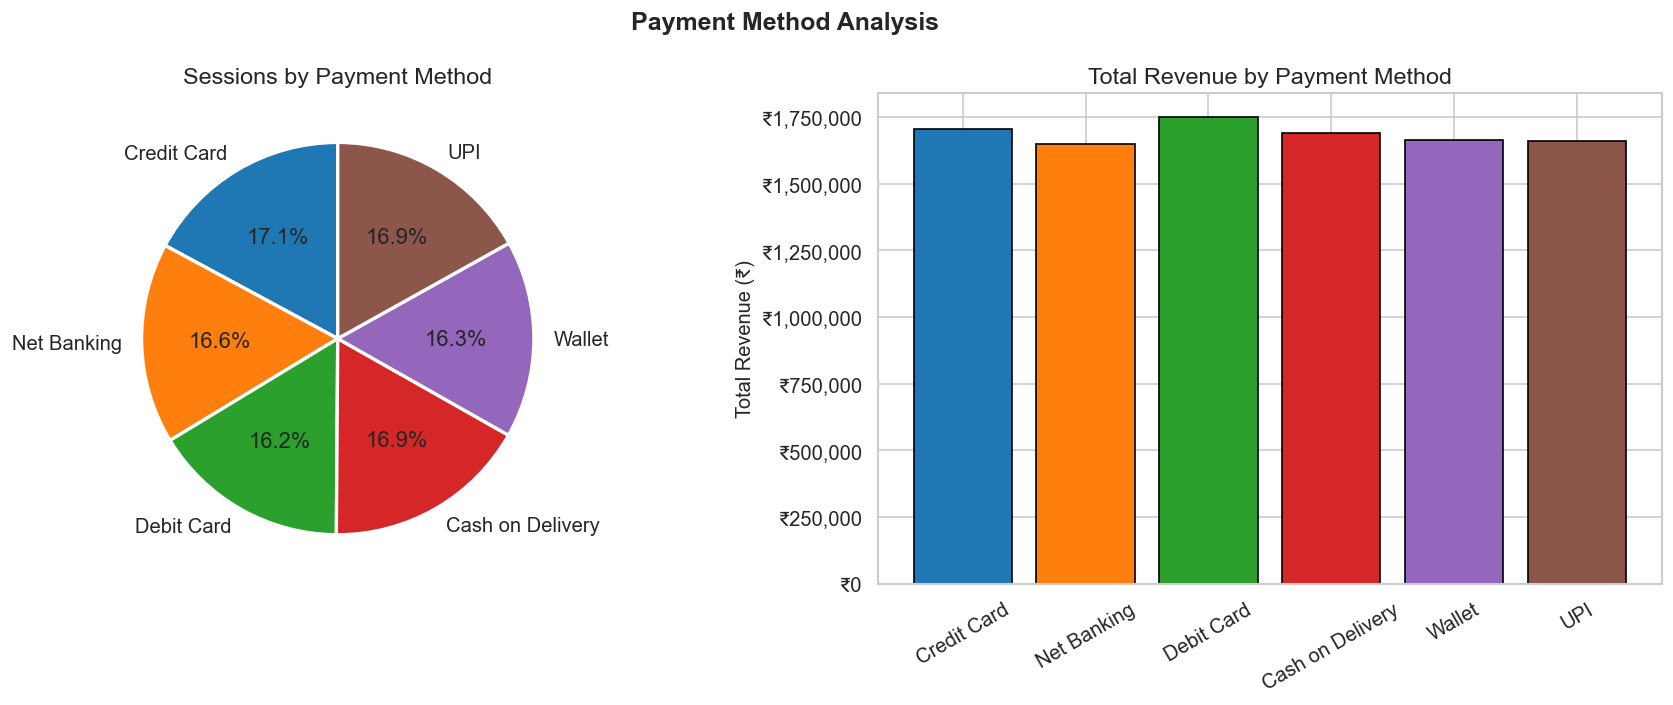

,payment_label,Sessions,Purchases,Conversion_Rate,Total_Revenue
1,Credit Card,4281,980,22.89,1704606.02
3,Net Banking,4140,949,22.92,1648044.55
2,Debit Card,4051,940,23.20,1750767.19
0,Cash on Delivery,4229,939,22.20,1691611.30
5,Wallet,4072,913,22.42,1662561.53
4,UPI,4227,895,21.17,1658578.47


In [20]:
pay_stats = df.groupby('payment_label').agg(
    Sessions=('session_id','count'),
    Purchases=('purchased','sum'),
    Total_Revenue=('revenue','sum'),
    Avg_Revenue=('revenue','mean')
).reset_index()
pay_stats['Conversion_Rate'] = (pay_stats['Purchases'] / pay_stats['Sessions'] * 100).round(2)
pay_stats = pay_stats.sort_values('Purchases', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

pal = sns.color_palette('tab10', len(pay_stats))

# Pie chart for sessions
axes[0].pie(pay_stats['Sessions'], labels=pay_stats['payment_label'],
            autopct='%1.1f%%', colors=pal, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Sessions by Payment Method')

# Bar for revenue
axes[1].bar(pay_stats['payment_label'], pay_stats['Total_Revenue'],
            color=pal, edgecolor='black')
axes[1].set_title('Total Revenue by Payment Method')
axes[1].set_ylabel('Total Revenue (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Payment Method Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
display(pay_stats[['payment_label','Sessions','Purchases','Conversion_Rate','Total_Revenue']].round(2))

---
## 11. Customer Rating & Review Analysis

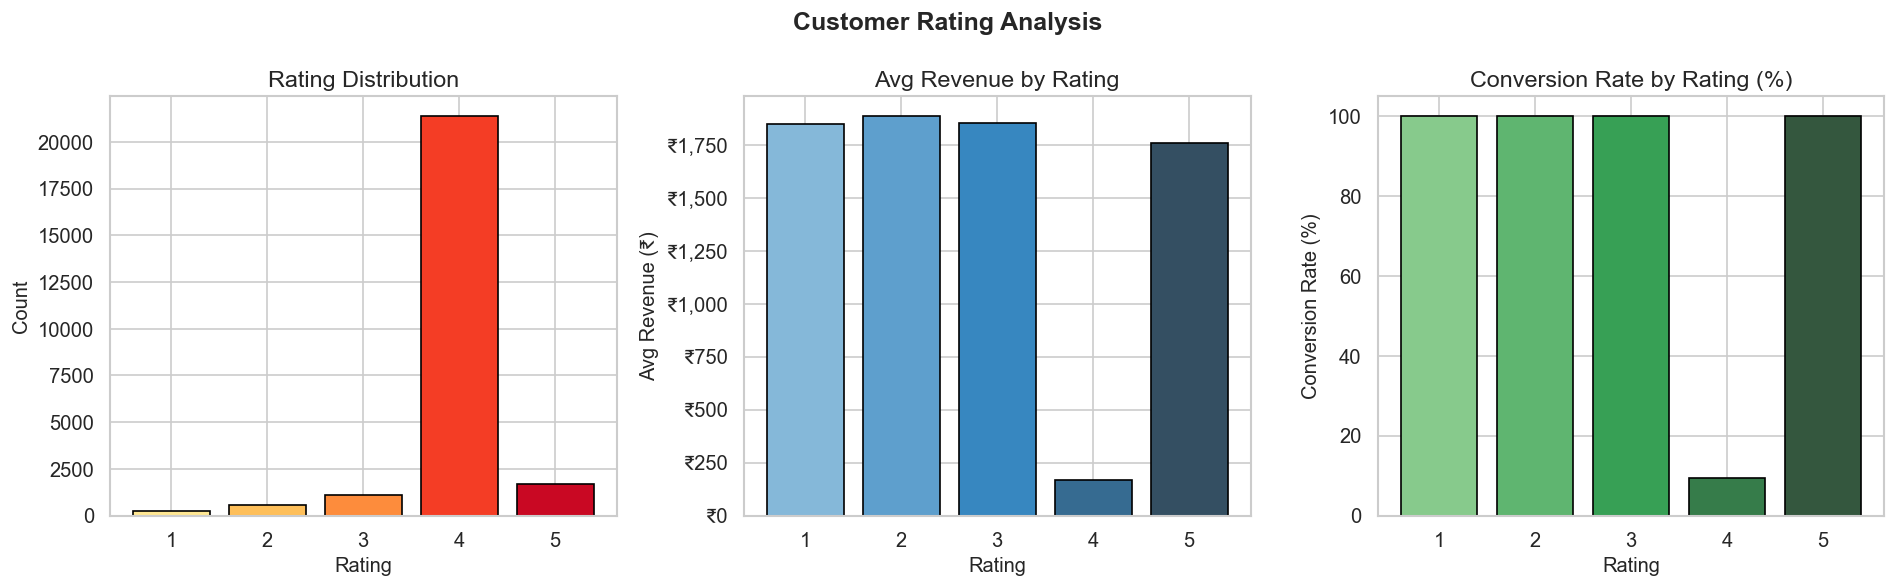

,rating,Count,Avg_Revenue,Purchase_Rate,Avg_Pages
0,1,262,1848.08,100.00,12.55
1,2,551,1883.67,100.00,12.90
2,3,1110,1851.33,100.00,12.40
3,4,21379,166.31,9.33,12.52
4,5,1698,1757.10,100.00,12.71


In [21]:
rating_stats = df.groupby('rating').agg(
    Count=('session_id','count'),
    Avg_Revenue=('revenue','mean'),
    Purchase_Rate=('purchased','mean'),
    Avg_Pages=('pages_viewed','mean')
).reset_index()
rating_stats['Purchase_Rate'] = (rating_stats['Purchase_Rate']*100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(rating_stats['rating'], rating_stats['Count'],
            color=sns.color_palette('YlOrRd', len(rating_stats)), edgecolor='black')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

axes[1].bar(rating_stats['rating'], rating_stats['Avg_Revenue'],
            color=sns.color_palette('Blues_d', len(rating_stats)), edgecolor='black')
axes[1].set_title('Avg Revenue by Rating')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Avg Revenue (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

axes[2].bar(rating_stats['rating'], rating_stats['Purchase_Rate'],
            color=sns.color_palette('Greens_d', len(rating_stats)), edgecolor='black')
axes[2].set_title('Conversion Rate by Rating (%)')
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Conversion Rate (%)')

plt.suptitle('Customer Rating Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
display(rating_stats.round(2))

---
## 12. Geographic (Location) Analysis

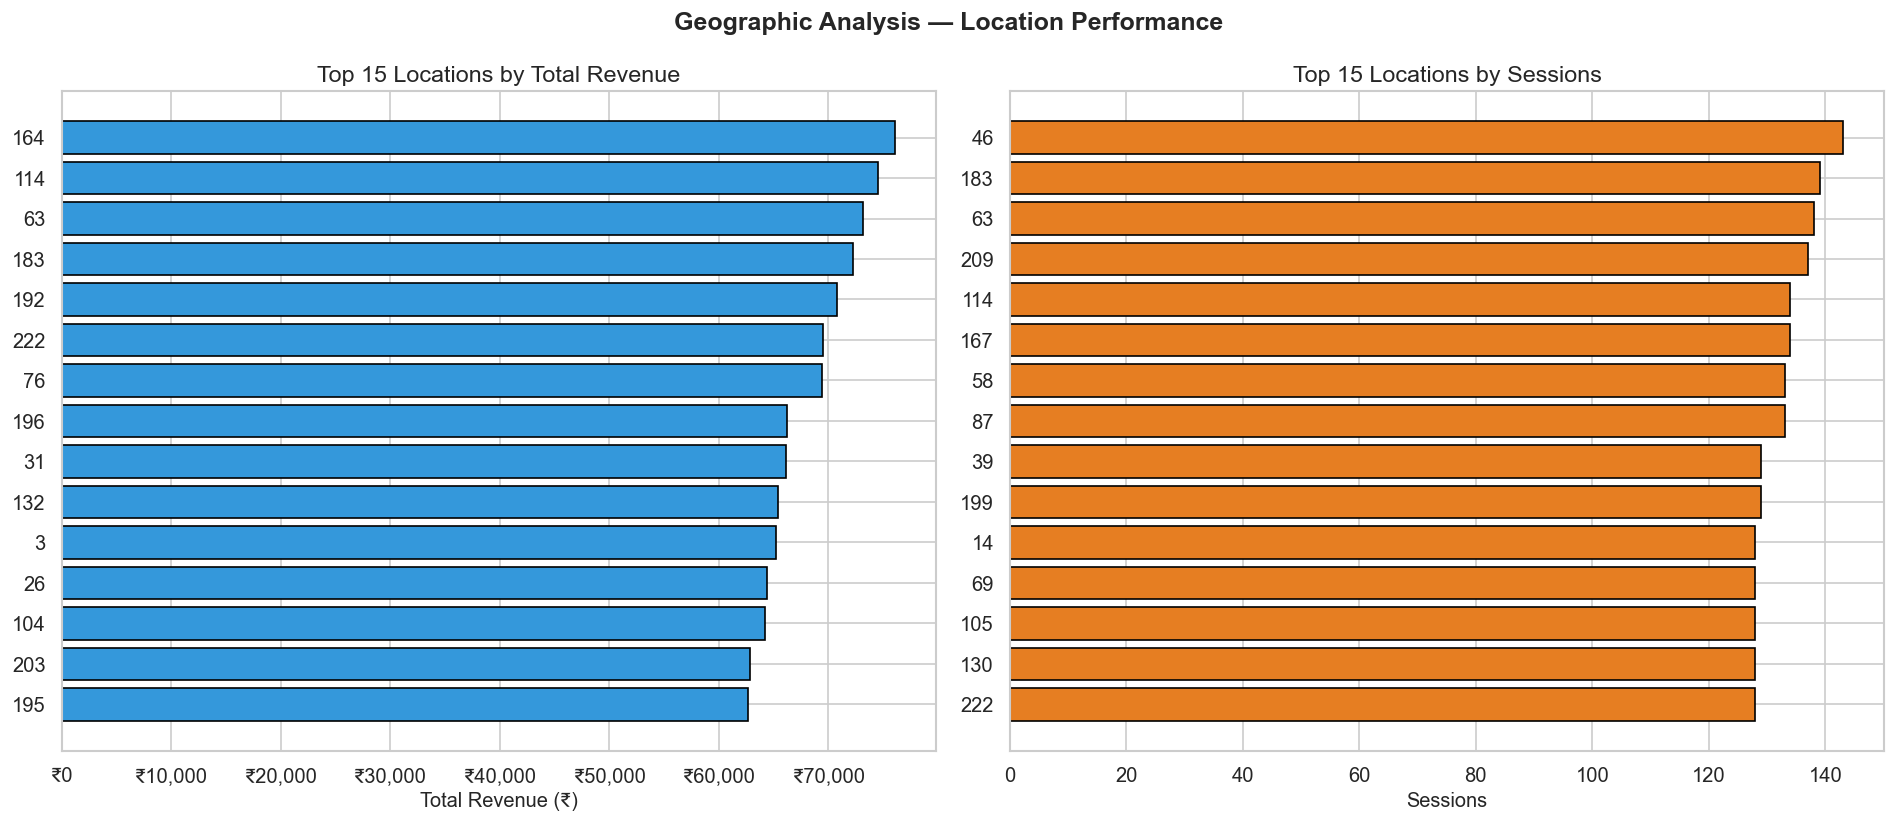

In [22]:
top_n = 15
loc_stats = df.groupby('location').agg(
    Sessions=('session_id','count'),
    Purchases=('purchased','sum'),
    Total_Revenue=('revenue','sum'),
    Avg_Revenue=('revenue','mean')
).reset_index()
loc_stats['Conversion_Rate'] = (loc_stats['Purchases'] / loc_stats['Sessions'] * 100).round(2)

top_rev = loc_stats.nlargest(top_n, 'Total_Revenue')
top_sessions = loc_stats.nlargest(top_n, 'Sessions')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_rev['location'].astype(str), top_rev['Total_Revenue'],
             color='#3498db', edgecolor='black')
axes[0].set_title(f'Top {top_n} Locations by Total Revenue')
axes[0].set_xlabel('Total Revenue (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
axes[0].invert_yaxis()

axes[1].barh(top_sessions['location'].astype(str), top_sessions['Sessions'],
             color='#e67e22', edgecolor='black')
axes[1].set_title(f'Top {top_n} Locations by Sessions')
axes[1].set_xlabel('Sessions')
axes[1].invert_yaxis()

plt.suptitle('Geographic Analysis — Location Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13. Interactive Plotly Dashboard

In [23]:
# ── KPI Summary Cards (fixed layout) ─────────────────────────────────────────
total_revenue   = df['revenue'].sum()
total_sessions  = len(df)
total_purchases = df['purchased'].sum()
conversion_rate = df['purchased'].mean() * 100
avg_order_value = df[df['revenue']>0]['revenue'].mean()
cart_abandon_r  = df['cart_abandoned'].mean() * 100

kpi_labels = [
    'Total Revenue',
    'Total Sessions',
    'Total Purchases',
    'Conversion Rate',
    'Avg Order Value',
    'Cart Abandon Rate'
]
kpi_values = [
    f'₹{total_revenue:,.0f}',
    f'{total_sessions:,}',
    f'{total_purchases:,}',
    f'{conversion_rate:.2f}%',
    f'₹{avg_order_value:,.2f}',
    f'{cart_abandon_r:.2f}%'
]
kpi_colors  = ['#27ae60', '#2980b9', '#8e44ad', '#e67e22', '#c0392b', '#16a085']
kpi_bg      = ['#eafaf1', '#eaf4fb', '#f5eef8', '#fef9e7', '#fdedec', '#e8f8f5']

# ── Use make_subplots so each Indicator gets its own isolated domain ──────────
fig = make_subplots(
    rows=1, cols=6,
    specs=[[{'type': 'indicator'}] * 6]
)

card_w = 1 / 6
gap    = 0.012

for i, (label, value, color) in enumerate(zip(kpi_labels, kpi_values, kpi_colors), start=1):
    fig.add_trace(
        go.Indicator(
            mode='number',
            value=0,
            number={'valueformat': '', 'font': {'size': 1, 'color': 'rgba(0,0,0,0)'}},
            title={
                'text': (
                    f'<span style="font-size:11px;color:#555;font-weight:600">{label}</span>'
                    f'<br><span style="font-size:18px;font-weight:700;color:{color}">{value}</span>'
                ),
                'font': {'size': 11},
                'align': 'center'
            },
            domain={
                'x': [(i - 1) * card_w + gap, i * card_w - gap],
                'y': [0.0, 1.0]
            }
        )
    )

# ── Add coloured background rectangle for each card ───────────────────────────
for i, bg in enumerate(kpi_bg):
    x0 = i * card_w + gap
    x1 = (i + 1) * card_w - gap
    fig.add_shape(
        type='rect',
        xref='paper', yref='paper',
        x0=x0, y0=0.05, x1=x1, y1=0.95,
        fillcolor=bg,
        line=dict(color=kpi_colors[i], width=1.5),
        layer='below'
    )

fig.update_layout(
    height=200,
    margin=dict(t=50, b=10, l=8, r=8),
    paper_bgcolor='#f8f9fa',
    plot_bgcolor='#f8f9fa',
    title=dict(
        text='<b>Indian E-Commerce — Key Performance Indicators</b>',
        font=dict(size=16, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    showlegend=False
)
fig.show()

In [24]:
# ── Multi-Panel Interactive Dashboard ─────────────────────────────────────────
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        'Monthly Revenue Trend',
        'Sessions by Marketing Channel',
        'Conversion Rate by Product Category',
        'Revenue Distribution by Device Type',
        'Discount % vs Revenue (Purchased Sessions)',
        'Heatmap: Purchases by Month × Weekday'
    ],
    specs=[
        [{'type':'scatter'}, {'type':'bar'}],
        [{'type':'bar'},     {'type':'pie'}],
        [{'type':'scatter'}, {'type':'heatmap'}]
    ]
)

# 1. Monthly Revenue Trend
fig.add_trace(
    go.Scatter(x=monthly_rev['month_name'], y=monthly_rev['Total_Revenue'],
               mode='lines+markers', name='Revenue',
               line=dict(color='#2980b9', width=3),
               marker=dict(size=8)),
    row=1, col=1
)

# 2. Sessions by Marketing Channel
channel_agg = df.groupby('channel_label')['session_id'].count().reset_index()
fig.add_trace(
    go.Bar(x=channel_agg['channel_label'], y=channel_agg['session_id'],
           name='Sessions', marker_color='#e67e22'),
    row=1, col=2
)

# 3. Conversion Rate by Category
cat_conv = df.groupby('category_label')['purchased'].mean().reset_index()
cat_conv['Conversion_Rate'] = cat_conv['purchased'] * 100
fig.add_trace(
    go.Bar(x=cat_conv['category_label'], y=cat_conv['Conversion_Rate'],
           name='Conversion Rate', marker_color='#8e44ad'),
    row=2, col=1
)

# 4. Revenue by Device Type (Pie)
dev_rev = df[df['revenue']>0].groupby('device_label')['revenue'].sum().reset_index()
fig.add_trace(
    go.Pie(labels=dev_rev['device_label'], values=dev_rev['revenue'],
           name='Device Revenue', hole=0.4),
    row=2, col=2
)

# 5. Discount vs Revenue scatter
sample = df[df['revenue']>0].sample(n=1500, random_state=1)
fig.add_trace(
    go.Scatter(x=sample['discount_percent'], y=sample['revenue'],
               mode='markers', name='Sessions',
               marker=dict(color=sample['rating'], colorscale='Viridis',
                           size=5, opacity=0.6, showscale=True,
                           colorbar=dict(title='Rating', x=0.45))),
    row=3, col=1
)

# 6. Heatmap: Purchases by Month x Weekday
heat_data = df[df['purchased']==1].groupby(
    ['visit_month','visit_weekday'])['purchased'].count().unstack(fill_value=0)
heat_data.index = [month_map.get(m, m) for m in heat_data.index]
heat_data.columns = [weekday_map.get(c, c) for c in heat_data.columns]

fig.add_trace(
    go.Heatmap(z=heat_data.values, x=list(heat_data.columns),
               y=list(heat_data.index), colorscale='YlOrRd',
               name='Purchases'),
    row=3, col=2
)

fig.update_layout(
    height=1100, showlegend=False,
    title_text='🛒  Indian E-Commerce — Interactive Analytics Dashboard',
    title_font_size=20,
    template='plotly_white'
)
fig.show()

---
## 14. Machine Learning — Purchase Prediction

### 14.1 Feature Preparation

In [25]:
# Select features for ML
feature_cols = [
    'device_type','user_type','marketing_channel','product_category',
    'unit_price','quantity','discount_percent','pages_viewed',
    'time_on_site_sec','added_to_cart','rating','review_helpful_votes',
    'payment_method','visit_month','visit_weekday','visit_season',
    'has_discount','time_on_site_min'
]
target_col = 'purchased'

ml_df = df[feature_cols + [target_col]].dropna()

X = ml_df[feature_cols]
y = ml_df[target_col]

print(f'Feature matrix shape : {X.shape}')
print(f'Target distribution  :\n{y.value_counts()}')
print(f'\nClass balance        : {y.mean()*100:.1f}% purchased')

Feature matrix shape : (25000, 18)
Target distribution  :
purchased
0    19384
1     5616
Name: count, dtype: int64

Class balance        : 22.5% purchased


### 14.2 Train/Test Split & Model Training

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=150, max_depth=10, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=120, learning_rate=0.1, max_depth=5, random_state=42
    )
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    results[name] = {'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
                     'Accuracy': acc, 'ROC-AUC': auc}
    print(f'{name:<25} Accuracy: {acc:.4f}   ROC-AUC: {auc:.4f}')

print('\n✅ All models trained.')

Logistic Regression       Accuracy: 0.9888   ROC-AUC: 0.9942


Random Forest             Accuracy: 0.9980   ROC-AUC: 0.9975


Gradient Boosting         Accuracy: 0.9972   ROC-AUC: 0.9971

✅ All models trained.


### 14.3 Model Comparison

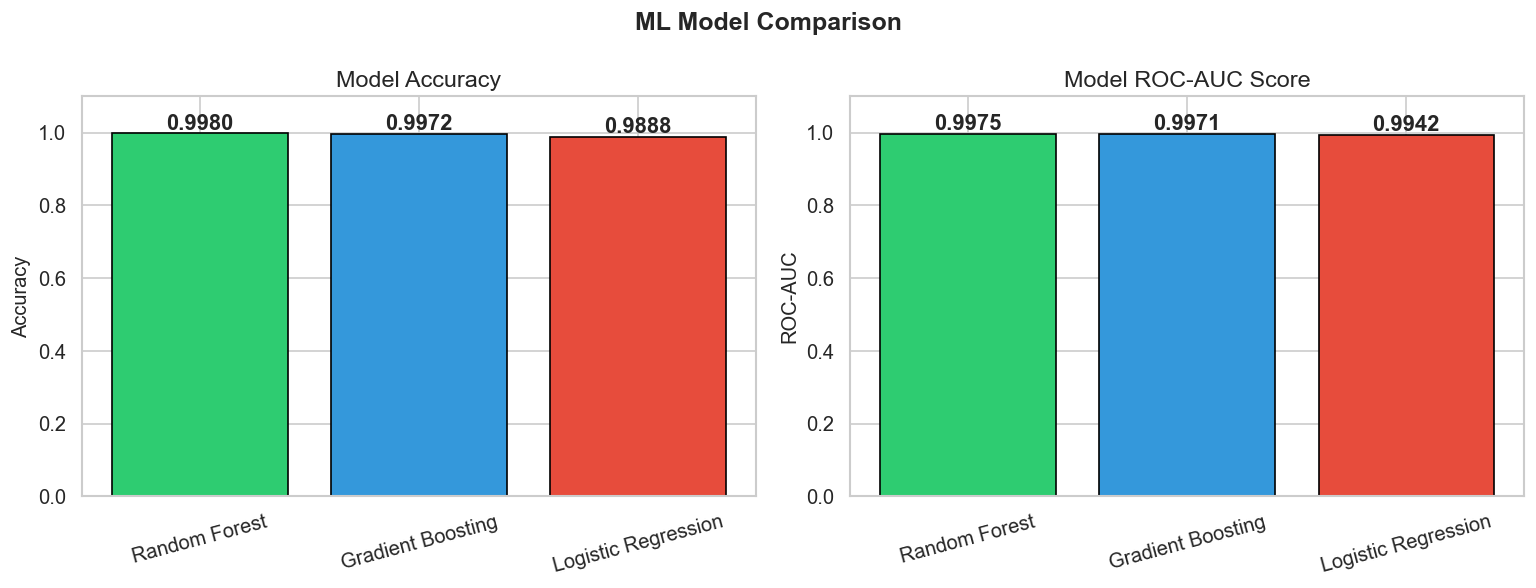

,Model,Accuracy,ROC-AUC
1,Random Forest,1.00,1.00
2,Gradient Boosting,1.00,1.00
0,Logistic Regression,0.99,0.99


In [27]:
summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results],
    'ROC-AUC':  [results[m]['ROC-AUC']  for m in results]
}).sort_values('ROC-AUC', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pal = ['#2ecc71','#3498db','#e74c3c']
axes[0].bar(summary_df['Model'], summary_df['Accuracy'], color=pal, edgecolor='black')
axes[0].set_title('Model Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

axes[1].bar(summary_df['Model'], summary_df['ROC-AUC'], color=pal, edgecolor='black')
axes[1].set_title('Model ROC-AUC Score')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.4f}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.suptitle('ML Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
display(summary_df)

### 14.4 Confusion Matrices

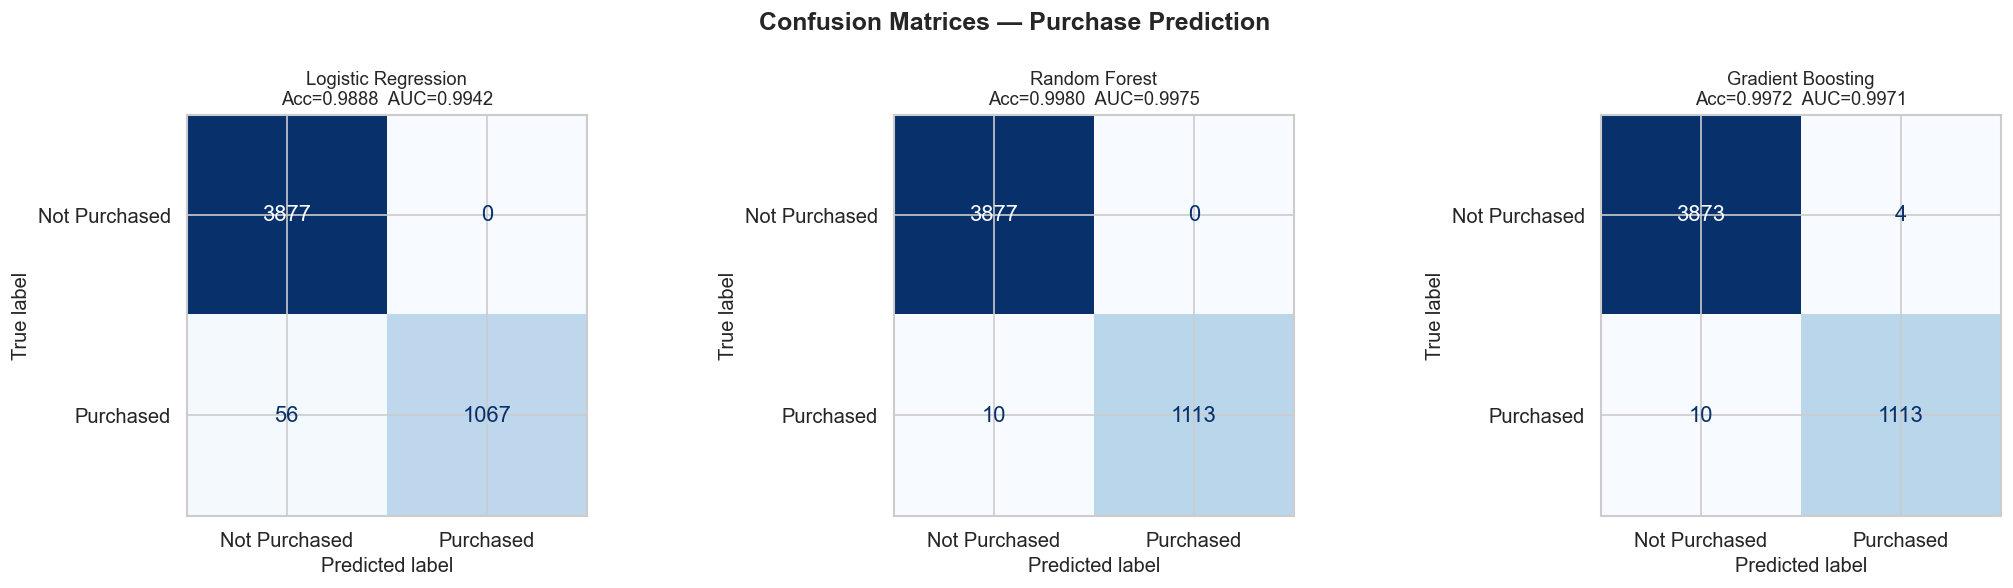

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased','Purchased'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nAcc={res["Accuracy"]:.4f}  AUC={res["ROC-AUC"]:.4f}', fontsize=11)

plt.suptitle('Confusion Matrices — Purchase Prediction', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 14.5 ROC Curves

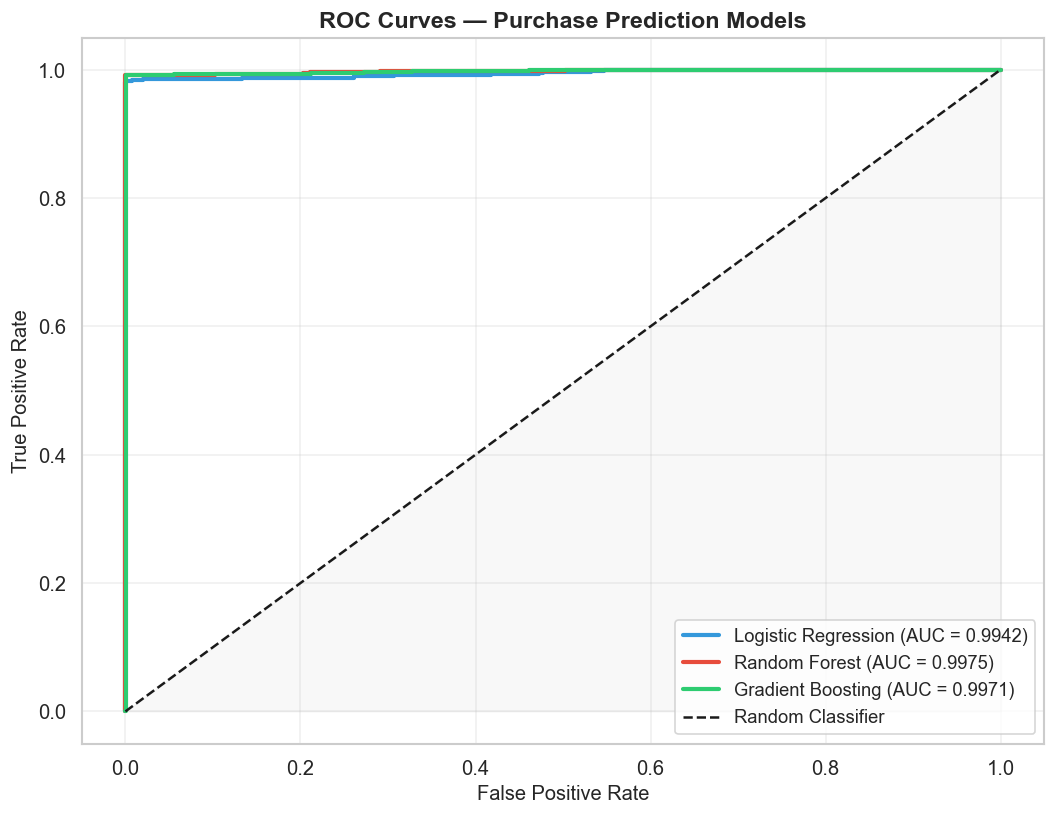

In [29]:
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#3498db','#e74c3c','#2ecc71']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f"{name} (AUC = {res['ROC-AUC']:.4f})")

ax.plot([0,1],[0,1],'k--', linewidth=1.5, label='Random Classifier')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Purchase Prediction Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 14.6 Feature Importance (Random Forest)

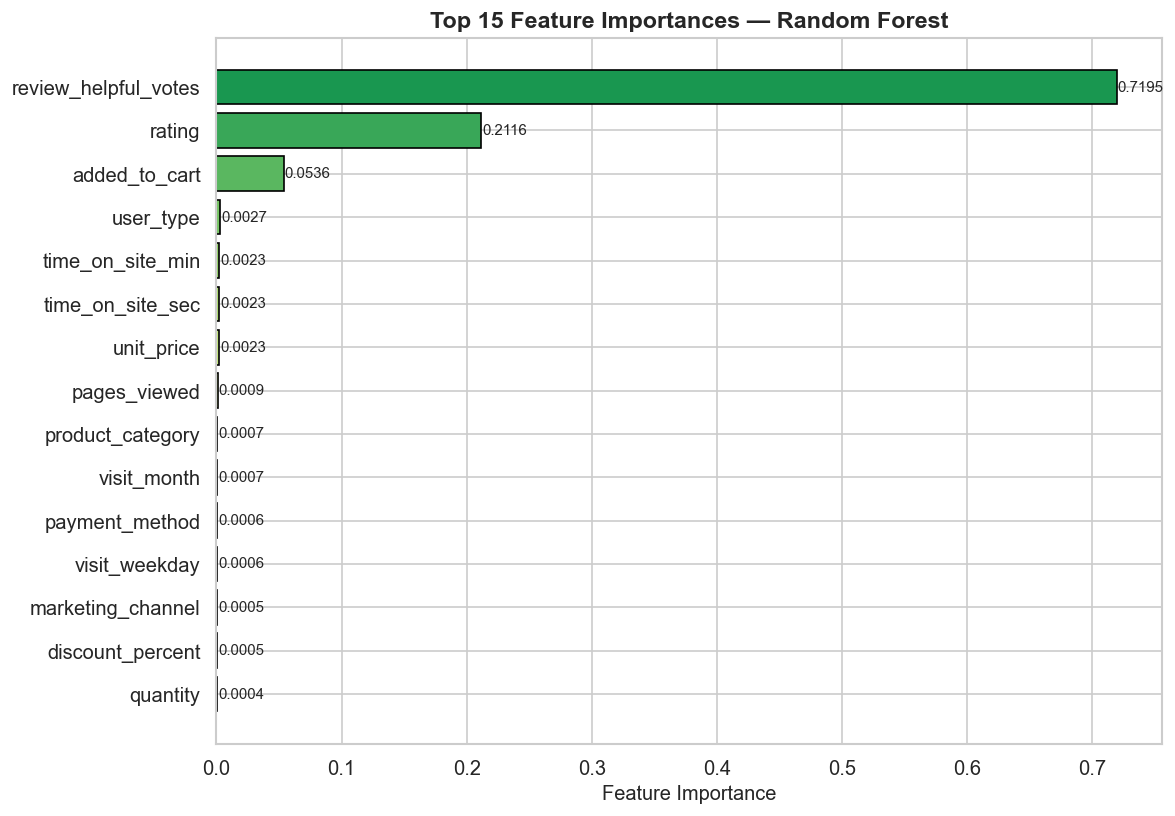

In [30]:
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})\
                .sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_imp_df)))
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors_imp, edgecolor='black')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
for i, v in enumerate(feat_imp_df['Importance']):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 14.7 Classification Report — Best Model

In [31]:
best_model_name = max(results, key=lambda m: results[m]['ROC-AUC'])
print(f'Best Model: {best_model_name}')
print('='*60)
print(classification_report(
    y_test, results[best_model_name]['y_pred'],
    target_names=['Not Purchased','Purchased']
))

Best Model: Random Forest
               precision    recall  f1-score   support

Not Purchased       1.00      1.00      1.00      3877
    Purchased       1.00      0.99      1.00      1123

     accuracy                           1.00      5000
    macro avg       1.00      1.00      1.00      5000
 weighted avg       1.00      1.00      1.00      5000



---
## 15. Key Insights & Business Recommendations

In [32]:
insights = {
    'Total Sessions'            : f'{total_sessions:,}',
    'Total Revenue (₹)'         : f'₹{total_revenue:,.2f}',
    'Total Purchases'           : f'{total_purchases:,}',
    'Overall Conversion Rate'   : f'{conversion_rate:.2f}%',
    'Average Order Value (₹)'   : f'₹{avg_order_value:,.2f}',
    'Cart Abandonment Rate'     : f'{cart_abandon_r:.2f}%',
    'Best ML Model'             : best_model_name,
    'Best Model ROC-AUC'        : f"{results[best_model_name]['ROC-AUC']:.4f}",
    'Top Revenue Category'      : cat_stats.iloc[0]['category_label'],
    'Top Marketing Channel'     : channel_stats.iloc[0]['channel_label'],
    'Highest Converting Device' : device_purchase.sort_values('Conversion Rate (%)', ascending=False).iloc[0]['Device']
}

print('='*65)
print('         INDIAN E-COMMERCE — PROJECT SUMMARY')
print('='*65)
for k, v in insights.items():
    print(f'  {k:<35} : {v}')
print('='*65)

print('''
KEY BUSINESS RECOMMENDATIONS
─────────────────────────────────────────────────────────────────
1. CART RECOVERY      — Implement email/push retargeting for
                        sessions where cart_abandoned = 1.

2. MOBILE OPTIMISATION— Mobile drives high session volume; invest
                        in UX/speed improvements for mobile checkout.

3. SEASONAL CAMPAIGNS — Align promotions with peak revenue seasons
                        identified in the seasonal analysis.

4. TARGETED DISCOUNTS — Discounts alone do not guarantee purchase;
                        combine with personalised product recommendations.

5. CHANNEL INVESTMENT — Double down on highest-ROI marketing channels
                        based on revenue-per-session metrics.

6. ML DEPLOYMENT      — Deploy the best ML model as a real-time
                        purchase-intent scorer to trigger dynamic
                        incentives during the browsing session.
─────────────────────────────────────────────────────────────────
''')

         INDIAN E-COMMERCE — PROJECT SUMMARY
  Total Sessions                      : 25,000
  Total Revenue (₹)                   : ₹10,116,169.06
  Total Purchases                     : 5,616
  Overall Conversion Rate             : 22.46%
  Average Order Value (₹)             : ₹1,801.31
  Cart Abandonment Rate               : 42.00%
  Best ML Model                       : Random Forest
  Best Model ROC-AUC                  : 0.9975
  Top Revenue Category                : Home & Kitchen
  Top Marketing Channel               : Direct
  Highest Converting Device           : Tablet

KEY BUSINESS RECOMMENDATIONS
─────────────────────────────────────────────────────────────────
1. CART RECOVERY      — Implement email/push retargeting for
                        sessions where cart_abandoned = 1.

2. MOBILE OPTIMISATION— Mobile drives high session volume; invest
                        in UX/speed improvements for mobile checkout.

3. SEASONAL CAMPAIGNS — Align promotions with peak revenue 

---
## 16. Web Application — Flask Backend (REST API)

This section builds a **Flask REST API** that serves all analytics data as JSON endpoints.  
Each route corresponds to one chart/table in the Plotly Dash frontend.  
The server runs on **port 5000** in a background thread when `main.py` is executed.

| Endpoint | Data served |
|---|---|
| `/api/kpi` | 6 top-level KPI metrics |
| `/api/monthly_revenue` | Monthly revenue & avg order value |
| `/api/device` | Conversion rate by device |
| `/api/category` | Revenue & conversion by product category |
| `/api/channel` | Marketing channel performance |
| `/api/payment` | Revenue by payment method |
| `/api/season` | Revenue by season |
| `/api/weekday` | Revenue by day of week |
| `/api/cart_abandonment` | Cart abandonment vs discount |
| `/api/rating` | Rating impact on revenue & purchase rate |
| `/api/location` | Top 15 locations by revenue |
| `/api/user_type` | New vs returning customer metrics |
| `/api/ml/results` | ML model accuracy & ROC-AUC |
| `/api/ml/feature_importance` | Random Forest feature importances |


### 16.1 Web Application Imports

In [ ]:
# ── Web Application Imports ──────────────────────────────────────────────────
# Install if needed:  pip install flask flask-cors dash requests
import os
import threading

from flask import Flask, jsonify
from flask_cors import CORS

import requests
import dash
from dash import dcc, html, Input, Output, dash_table
import plotly.graph_objects as go
import plotly.express       as px
from plotly.subplots        import make_subplots

print('Web application libraries imported successfully.')


### 16.2 Configuration & Colour Palette

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
FLASK_PORT = 5000
DASH_PORT  = 8050
API_BASE   = f'http://127.0.0.1:{FLASK_PORT}/api'

# Resolve CSV path relative to this notebook
CSV_PATH = os.path.join(os.getcwd(), 'Ecommerce.csv')

# ── Colour palette (shared by backend and frontend) ──────────────────────────
COLORS = {
    'bg':      '#f7f9fc',
    'card':    '#ffffff',
    'accent1': '#3b82f6',
    'accent2': '#10b981',
    'accent3': '#f59e0b',
    'accent4': '#ef4444',
    'accent5': '#8b5cf6',
    'accent6': '#06b6d4',
    'text':    '#1e293b',
    'muted':   '#64748b',
    'border':  '#e2e8f0',
}
PALETTE = [COLORS['accent1'], COLORS['accent2'], COLORS['accent3'],
           COLORS['accent4'], COLORS['accent5'], COLORS['accent6'],
           '#f97316', '#84cc16']

print(f'Flask port : {FLASK_PORT}')
print(f'Dash port  : {DASH_PORT}')
print(f'CSV path   : {CSV_PATH}')


### 16.3 Flask Server — Data Loading & Feature Engineering

In [ ]:
# ── Ensure pandas is available (already imported above in cell 3) ──────────
import pandas as pd

# ── Flask server instance ────────────────────────────────────────────────────
server = Flask(__name__)
CORS(server)   # allow cross-origin requests from Dash (different port)

# ── Data loading & feature engineering ───────────────────────────────────────
def load_data():
    _df = pd.read_csv(CSV_PATH)
    _df['visit_date'] = pd.to_datetime(_df['visit_date'], format='%d-%m-%Y')
    _df['device_label']   = _df['device_type'].map({0:'Desktop',1:'Mobile',2:'Tablet'})
    _df['user_label']     = _df['user_type'].map({0:'New',1:'Returning'})
    _df['channel_label']  = _df['marketing_channel'].map(
        {0:'Organic',1:'Email',2:'Social Media',3:'Referral',4:'Paid Search',5:'Direct'})
    _df['category_label'] = _df['product_category'].map(
        {0:'Electronics',1:'Fashion',2:'Home & Kitchen',3:'Sports',
         4:'Books',5:'Beauty',6:'Toys',7:'Grocery'})
    _df['payment_label']  = _df['payment_method'].map(
        {0:'UPI',1:'Credit Card',2:'Debit Card',3:'Net Banking',4:'COD',5:'Wallet'})
    _df['season_label']   = _df['visit_season'].map(
        {0:'Winter',1:'Spring',2:'Summer',3:'Autumn'})
    _df['weekday_label']  = _df['visit_weekday'].map(
        {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',
         4:'Friday',5:'Saturday',6:'Sunday'})
    _df['time_on_site_min'] = (_df['time_on_site_sec'] / 60).round(2)
    _df['total_spend']      = (_df['unit_price'] * _df['quantity']).round(2)
    _df['has_discount']     = (_df['discount_percent'] > 0).astype(int)
    _df['month_name']       = _df['visit_date'].dt.strftime('%b')
    return _df

# ── ML training for API ───────────────────────────────────────────────────────
def train_models_api(_df):
    from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.linear_model    import LogisticRegression
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline        import Pipeline
    from sklearn.preprocessing   import StandardScaler
    from sklearn.metrics         import accuracy_score, roc_auc_score, \
                                        classification_report, confusion_matrix

    _feature_cols = [
        'device_type','user_type','marketing_channel','product_category',
        'unit_price','quantity','discount_percent','pages_viewed',
        'time_on_site_sec','added_to_cart','rating','review_helpful_votes',
        'payment_method','visit_month','visit_weekday','visit_season',
        'has_discount','total_spend',
    ]
    _X = _df[_feature_cols].fillna(0)
    _y = _df['purchased']
    _Xtr, _Xte, _ytr, _yte = train_test_split(
        _X, _y, test_size=0.2, random_state=42, stratify=_y)

    _models = {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(max_iter=500, random_state=42))]),
        'Random Forest': RandomForestClassifier(
            n_estimators=150, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=150, random_state=42),
    }
    _res = {}
    for _name, _model in _models.items():
        _model.fit(_Xtr, _ytr)
        _yp  = _model.predict(_Xte)
        _ya  = _model.predict_proba(_Xte)[:, 1]
        _res[_name] = {
            'Accuracy': round(accuracy_score(_yte, _yp) * 100, 2),
            'ROC-AUC':  round(roc_auc_score(_yte, _ya) * 100, 2),
            'confusion_matrix': confusion_matrix(_yte, _yp).tolist(),
            'report': classification_report(
                _yte, _yp,
                target_names=['Not Purchased','Purchased'],
                output_dict=True),
            'model': _model,
        }
    _rf     = _res['Random Forest']['model']
    _imp_df = (pd.DataFrame({'feature': _feature_cols,
                              'importance': _rf.feature_importances_})
               .sort_values('importance', ascending=False).head(15))
    return _res, _imp_df

print('Loading data for web app...')
DF_WEB = load_data()
print(f'  {len(DF_WEB):,} rows loaded.')
print('Training ML models for API...')
ML_RESULTS_WEB, FEAT_IMP_WEB = train_models_api(DF_WEB)
print('  Models ready.')


### 16.4 Flask API Routes

In [ ]:
def _clean(results):
    return {n: {k: v for k, v in r.items() if k != 'model'}
            for n, r in results.items()}

# ── /api/kpi ──────────────────────────────────────────────────────────────────
@server.route('/api/kpi')
def api_kpi():
    return jsonify({
        'total_sessions':    int(len(DF_WEB)),
        'total_revenue':     round(float(DF_WEB['revenue'].sum()), 2),
        'total_purchases':   int(DF_WEB['purchased'].sum()),
        'conversion_rate':   round(float(DF_WEB['purchased'].mean() * 100), 2),
        'avg_order_value':   round(float(DF_WEB[DF_WEB['revenue'] > 0]['revenue'].mean()), 2),
        'cart_abandon_rate': round(float(DF_WEB['cart_abandoned'].mean() * 100), 2),
    })

# ── /api/monthly_revenue ─────────────────────────────────────────────────────
@server.route('/api/monthly_revenue')
def api_monthly():
    mo = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    m  = (DF_WEB[DF_WEB['revenue'] > 0]
          .groupby('month_name')
          .agg(Total_Revenue=('revenue','sum'),
               Transactions=('purchased','sum'),
               Avg_Order_Value=('revenue','mean'))
          .reindex(mo).dropna().reset_index().round(2))
    return jsonify(m.to_dict(orient='records'))

# ── /api/device ───────────────────────────────────────────────────────────────
@server.route('/api/device')
def api_device():
    d = DF_WEB.groupby('device_label')['purchased'].agg(['sum','count']).reset_index()
    d.columns = ['device','purchases','sessions']
    d['conversion_rate'] = (d['purchases'] / d['sessions'] * 100).round(2)
    return jsonify(d.to_dict(orient='records'))

# ── /api/category ─────────────────────────────────────────────────────────────
@server.route('/api/category')
def api_category():
    c = (DF_WEB.groupby('category_label')
           .agg(Total_Revenue=('revenue','sum'),
                Sessions=('session_id','count'),
                Purchases=('purchased','sum'),
                Avg_Rating=('rating','mean'))
           .reset_index().round(2))
    c['conversion_rate'] = (c['Purchases'] / c['Sessions'] * 100).round(2)
    return jsonify(c.to_dict(orient='records'))

# ── /api/channel ──────────────────────────────────────────────────────────────
@server.route('/api/channel')
def api_channel():
    ch = (DF_WEB.groupby('channel_label')
            .agg(Sessions=('session_id','count'),
                 Purchases=('purchased','sum'),
                 Total_Revenue=('revenue','sum'),
                 Cart_Abandon=('cart_abandoned','mean'))
            .reset_index().round(2))
    ch['conversion_rate'] = (ch['Purchases'] / ch['Sessions'] * 100).round(2)
    return jsonify(ch.to_dict(orient='records'))

# ── /api/payment ──────────────────────────────────────────────────────────────
@server.route('/api/payment')
def api_payment():
    p = (DF_WEB.groupby('payment_label')
           .agg(Sessions=('session_id','count'),
                Purchases=('purchased','sum'),
                Total_Revenue=('revenue','sum'),
                Avg_Revenue=('revenue','mean'))
           .reset_index().round(2))
    p['conversion_rate'] = (p['Purchases'] / p['Sessions'] * 100).round(2)
    return jsonify(p.to_dict(orient='records'))

# ── /api/season ───────────────────────────────────────────────────────────────
@server.route('/api/season')
def api_season():
    s = (DF_WEB.groupby('season_label')
           .agg(Total_Revenue=('revenue','sum'),
                Sessions=('session_id','count'),
                Avg_Revenue=('revenue','mean'))
           .reset_index().round(2))
    return jsonify(s.to_dict(orient='records'))

# ── /api/weekday ──────────────────────────────────────────────────────────────
@server.route('/api/weekday')
def api_weekday():
    dow = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    w   = (DF_WEB[DF_WEB['revenue'] > 0]
           .groupby('weekday_label')['revenue']
           .agg(['sum','mean','count'])
           .reindex(dow).reset_index().round(2))
    w.columns = ['weekday','total_revenue','avg_revenue','transactions']
    return jsonify(w.to_dict(orient='records'))

# ── /api/cart_abandonment ─────────────────────────────────────────────────────
@server.route('/api/cart_abandonment')
def api_cart():
    c = DF_WEB.groupby(['has_discount','cart_abandoned']).size().reset_index(name='count')
    c['discount_label'] = c['has_discount'].map({0:'No Discount',1:'Has Discount'})
    c['cart_label']     = c['cart_abandoned'].map({0:'Not Abandoned',1:'Abandoned'})
    return jsonify(c.to_dict(orient='records'))

# ── /api/rating ───────────────────────────────────────────────────────────────
@server.route('/api/rating')
def api_rating():
    r = (DF_WEB.groupby('rating')
           .agg(Count=('session_id','count'),
                Avg_Revenue=('revenue','mean'),
                Purchase_Rate=('purchased','mean'))
           .reset_index().round(2))
    r['Purchase_Rate'] = (r['Purchase_Rate'] * 100).round(2)
    return jsonify(r.to_dict(orient='records'))

# ── /api/location ─────────────────────────────────────────────────────────────
@server.route('/api/location')
def api_location():
    loc = (DF_WEB.groupby('location')
             .agg(Sessions=('session_id','count'),
                  Total_Revenue=('revenue','sum'),
                  Purchases=('purchased','sum'))
             .reset_index()
             .sort_values('Total_Revenue', ascending=False)
             .head(15).round(2))
    loc['conversion_rate'] = (loc['Purchases'] / loc['Sessions'] * 100).round(2)
    return jsonify(loc.to_dict(orient='records'))

# ── /api/user_type ────────────────────────────────────────────────────────────
@server.route('/api/user_type')
def api_user_type():
    u = (DF_WEB.groupby('user_label')
           .agg(Sessions=('session_id','count'),
                Avg_Revenue=('revenue','mean'),
                Conversion_Rate=('purchased','mean'),
                Avg_Pages=('pages_viewed','mean'),
                Avg_Time_Min=('time_on_site_min','mean'))
           .reset_index().round(2))
    u['Conversion_Rate'] = (u['Conversion_Rate'] * 100).round(2)
    return jsonify(u.to_dict(orient='records'))

# ── /api/ml/results  &  /api/ml/feature_importance ───────────────────────────
@server.route('/api/ml/results')
def api_ml_results():
    return jsonify(_clean(ML_RESULTS_WEB))

@server.route('/api/ml/feature_importance')
def api_feature_importance():
    return jsonify(FEAT_IMP_WEB.to_dict(orient='records'))

@server.route('/api/health')
def api_health():
    return jsonify({'status': 'ok', 'rows': len(DF_WEB)})

print('All Flask API routes registered.')
print('Available endpoints:')
for rule in server.url_map.iter_rules():
    print(f'  {rule}')


---
## 17. Web Application — Plotly Dash Frontend (Interactive Dashboard)

This section builds the **Plotly Dash** interactive frontend — 100% Python, no HTML or JavaScript required.  
The dashboard has **6 tabs**, each populated by fetching data from the Flask API above.

| Tab | Contents |
|---|---|
| 📊 Overview | 6 KPI cards + monthly revenue + seasonal + device/user breakdown |
| 📅 Sales & Time | Monthly dual-axis, day-of-week, seasonal bars |
| 🏷️ Products | Category revenue, rating impact, top-15 locations |
| 📣 Marketing | Channel grouped bar, payment donut, cart abandonment |
| 👤 Customers | New vs returning, device breakdown, rating analysis |
| 🤖 Machine Learning | Model table, accuracy/AUC bars, feature importances |


### 17.1 Dash — Helper Functions & Chart Factories

In [ ]:
# ── Helper: safe GET from Flask API ─────────────────────────────────────────
def fetch(endpoint):
    try:
        r = requests.get(f'{API_BASE}/{endpoint}', timeout=15)
        r.raise_for_status()
        return r.json()
    except Exception as e:
        print(f'[WARN] fetch /{endpoint} failed: {e}')
        return []

# ── Shared chart layout ───────────────────────────────────────────────────────
def _layout(title):
    return dict(
        title=dict(text=title, font=dict(size=15, color=COLORS['text']), x=0.02),
        plot_bgcolor=COLORS['card'], paper_bgcolor=COLORS['card'],
        font=dict(family='system-ui, -apple-system, sans-serif', color=COLORS['text']),
        margin=dict(l=40, r=20, t=50, b=40),
        legend=dict(bgcolor='rgba(0,0,0,0)'), showlegend=True,
    )

# ── KPI card component ────────────────────────────────────────────────────────
def card(title, value, subtitle='', color=COLORS['accent1']):
    return html.Div([
        html.P(title, style={'margin':0,'fontSize':'12px','color':COLORS['muted'],
                             'textTransform':'uppercase','letterSpacing':'0.05em'}),
        html.H3(value, style={'margin':'4px 0 2px','fontSize':'26px',
                               'fontWeight':'700','color':color}),
        html.P(subtitle, style={'margin':0,'fontSize':'11px','color':COLORS['muted']}),
    ], style={
        'background':COLORS['card'], 'borderRadius':'12px',
        'padding':'20px 24px', 'flex':'1',
        'borderLeft':f'4px solid {color}',
        'boxShadow':'0 1px 4px rgba(0,0,0,0.07)', 'minWidth':'150px',
    })

def build_kpi_row():
    kpi = fetch('kpi')
    if not kpi:
        return html.Div('Backend initialising — please refresh.',
                        style={'color':COLORS['accent4'],'padding':'20px'})
    return html.Div([
        card('Total Sessions',    f'{kpi["total_sessions"]:,}',
             'customer sessions in 2024',  COLORS['accent1']),
        card('Total Revenue',     f'\u20b9{kpi["total_revenue"]:,.0f}',
             'cumulative revenue',         COLORS['accent2']),
        card('Total Purchases',   f'{kpi["total_purchases"]:,}',
             'completed transactions',     COLORS['accent3']),
        card('Conversion Rate',   f'{kpi["conversion_rate"]}%',
             'session \u2192 purchase',    COLORS['accent5']),
        card('Avg Order Value',   f'\u20b9{kpi["avg_order_value"]:,.0f}',
             'per purchased session',      COLORS['accent6']),
        card('Cart Abandon Rate', f'{kpi["cart_abandon_rate"]}%',
             'sessions abandoned cart',    COLORS['accent4']),
    ], style={'display':'flex','gap':'16px','flexWrap':'wrap','marginBottom':'24px'})

# ── Layout wrappers ───────────────────────────────────────────────────────────
def section(title, *children):
    return html.Div([
        html.H2(title, style={
            'fontSize':'17px','fontWeight':'700','color':COLORS['text'],
            'margin':'28px 0 14px',
            'borderBottom':f'2px solid {COLORS["accent1"]}',
            'paddingBottom':'6px'}),
        *children,
    ])

def two_col(*items):
    return html.Div([
        html.Div(item, style={
            'flex':'1','minWidth':'300px',
            'background':COLORS['card'],'borderRadius':'12px',
            'boxShadow':'0 1px 4px rgba(0,0,0,0.07)','overflow':'hidden'})
        for item in items
    ], style={'display':'flex','gap':'16px','flexWrap':'wrap'})

# ── Chart factories ───────────────────────────────────────────────────────────
def chart_monthly_revenue():
    data = fetch('monthly_revenue')
    if not data: return dcc.Graph()
    months = [d['month_name']      for d in data]
    rev    = [d['Total_Revenue']   for d in data]
    aov    = [d['Avg_Order_Value'] for d in data]
    fig = make_subplots(specs=[[{'secondary_y': True}]])
    fig.add_trace(go.Bar(x=months, y=rev, name='Total Revenue',
                         marker_color=COLORS['accent1'], opacity=0.85))
    fig.add_trace(go.Scatter(x=months, y=aov, name='Avg Order Value',
                             mode='lines+markers',
                             line=dict(color=COLORS['accent3'], width=2.5)),
                  secondary_y=True)
    fig.update_layout(**_layout('Monthly Revenue Trend'))
    fig.update_yaxes(title_text='Revenue (\u20b9)', secondary_y=False)
    fig.update_yaxes(title_text='Avg Order Value (\u20b9)', secondary_y=True)
    return dcc.Graph(figure=fig, config={'displayModeBar': False})

def chart_device():
    data = fetch('device')
    if not data: return dcc.Graph()
    fig = px.bar(data, x='device', y='conversion_rate', color='device',
                 color_discrete_sequence=PALETTE, text='conversion_rate',
                 labels={'conversion_rate':'Conversion Rate (%)','device':'Device'})
    fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
    fig.update_layout(**_layout('Conversion Rate by Device'))
    return dcc.Graph(figure=fig, config={'displayModeBar': False})

def chart_category():
    data = fetch('category')
    if not data: return dcc.Graph()
    fig = px.bar(data, x='category_label', y='Total_Revenue',
                 color='category_label', color_discrete_sequence=PALETTE,
                 text='Total_Revenue',
                 labels={'Total_Revenue':'Revenue (\u20b9)','category_label':'Category'})
    fig.update_traces(texttemplate='\u20b9%{text:,.0f}', textposition='outside')
    fig.update_layout(**_layout('Revenue by Product Category'))
    return dcc.Graph(figure=fig, config={'displayModeBar': False})

def chart_channel():
    data = fetch('channel')
    if not data: return dcc.Graph()
    fig = px.bar(data, x='channel_label', y=['Sessions','Purchases','Total_Revenue'],
                 barmode='group', color_discrete_sequence=PALETTE,
                 labels={'value':'Count / Revenue','channel_label':'Channel','variable':'Metric'})
    fig.update_layout(**_layout('Marketing Channel Performance'))
    return dcc.Graph(figure=fig, config={'displayModeBar': False})

def chart_payment():
    data = fetch('payment')
    if not data: return dcc.Graph()
    fig = px.pie(data, names='payment_label', values='Total_Revenue',
                 color_discrete_sequence=PALETTE, hole=0.4)
    fig.update_layout(**_layout('Revenue Share by Payment Method'))
    return dcc.Graph(figure=fig, config={'displayModeBar': False})

def chart_season():
    data = fetch('season')
    if not data: return dcc.Graph()
    fig = px.bar(data, x='season_label', y='Total_Revenue',
                 color='season_label', color_discrete_sequence=PALETTE,
                 text='Total_Revenue',
                 labels={'Total_Revenue':'Revenue (\u20b9)','season_label':'Season'})
    fig.update_traces(texttemplate='\u20b9%{text:,.0f}', textposition='outside')
    fig.update_layout(**_layout('Revenue by Season'))
    return dcc.Graph(figure=fig, config={'displayModeBar': False})

def chart_weekday():
    data = fetch('weekday')
    if not data: return dcc.Graph()
    fig = px.bar(data, x='weekday', y='total_revenue',
                 color='weekday', color_discrete_sequence=PALETTE,
                 text='total_revenue',
                 labels={'total_revenue':'Revenue (\u20b9)','weekday':'Day'})
    fig.update_traces(texttemplate='\u20b9%{text:,.0f}', textposition='outside')
    fig.update_layout(**_layout('Revenue by Day of Week'))
    return dcc.Graph(figure=fig, config={'displayModeBar': False})

def chart_cart():
    data = fetch('cart_abandonment')
    if not data: return dcc.Graph()
    fig = px.bar(data, x='discount_label', y='count',
                 color='cart_label', barmode='group',
                 color_discrete_sequence=[COLORS['accent2'], COLORS['accent4']],
                 labels={'count':'Sessions','discount_label':'Discount Status',
                         'cart_label':'Cart Status'})
    fig.update_layout(**_layout('Cart Abandonment vs Discount'))
    return dcc.Graph(figure=fig, config={'displayModeBar': False})

def chart_rating():
    data = fetch('rating')
    if not data: return dcc.Graph()
    fig = make_subplots(specs=[[{'secondary_y': True}]])
    ratings = [d['rating']        for d in data]
    rev     = [d['Avg_Revenue']   for d in data]
    pr      = [d['Purchase_Rate'] for d in data]
    fig.add_trace(go.Bar(x=ratings, y=rev, name='Avg Revenue',
                         marker_color=COLORS['accent1']))
    fig.add_trace(go.Scatter(x=ratings, y=pr, name='Purchase Rate (%)',
                             mode='lines+markers',
                             line=dict(color=COLORS['accent3'], width=2.5)),
                  secondary_y=True)
    fig.update_xaxes(title_text='Rating (1\u20135)')
    fig.update_yaxes(title_text='Avg Revenue (\u20b9)', secondary_y=False)
    fig.update_yaxes(title_text='Purchase Rate (%)', secondary_y=True)
    fig.update_layout(**_layout('Rating Impact on Revenue & Purchase Rate'))
    return dcc.Graph(figure=fig, config={'displayModeBar': False})

def chart_location():
    data = fetch('location')
    if not data: return dcc.Graph()
    fig = px.bar(data, x='Total_Revenue', y='location', orientation='h',
                 color='Total_Revenue', color_continuous_scale='Blues',
                 labels={'Total_Revenue':'Revenue (\u20b9)','location':'Location ID'})
    fig.update_layout(**_layout('Top 15 Locations by Revenue'))
    return dcc.Graph(figure=fig, config={'displayModeBar': False})

def chart_user_type():
    data = fetch('user_type')
    if not data: return dcc.Graph()
    fig = px.bar(data, x='user_label', y='Conversion_Rate',
                 color='user_label', color_discrete_sequence=PALETTE,
                 text='Conversion_Rate',
                 labels={'Conversion_Rate':'Conversion Rate (%)','user_label':'User Type'})
    fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
    fig.update_layout(**_layout('New vs Returning: Conversion Rate'))
    return dcc.Graph(figure=fig, config={'displayModeBar': False})

def chart_ml_accuracy():
    data = fetch('ml/results')
    if not data: return dcc.Graph()
    names = list(data.keys())
    acc   = [data[n]['Accuracy'] for n in names]
    auc   = [data[n]['ROC-AUC']  for n in names]
    fig = go.Figure()
    fig.add_trace(go.Bar(name='Accuracy (%)', x=names, y=acc,
                         marker_color=COLORS['accent1'], text=acc,
                         texttemplate='%{text:.2f}%', textposition='outside'))
    fig.add_trace(go.Bar(name='ROC-AUC (%)', x=names, y=auc,
                         marker_color=COLORS['accent2'], text=auc,
                         texttemplate='%{text:.2f}%', textposition='outside'))
    fig.update_layout(barmode='group', **_layout('ML Model Performance Comparison'))
    return dcc.Graph(figure=fig, config={'displayModeBar': False})

def chart_feature_importance():
    data = fetch('ml/feature_importance')
    if not data: return dcc.Graph()
    data_sorted = sorted(data, key=lambda x: x['importance'])
    feats = [d['feature']    for d in data_sorted]
    imps  = [d['importance'] for d in data_sorted]
    fig = go.Figure(go.Bar(x=imps, y=feats, orientation='h',
                           marker_color=COLORS['accent5']))
    fig.update_layout(**_layout('Random Forest \u2013 Top Feature Importances'))
    return dcc.Graph(figure=fig, config={'displayModeBar': False})

def table_ml_results():
    data = fetch('ml/results')
    if not data: return html.Div()
    rows = [{'Model': n, 'Accuracy (%)': v['Accuracy'], 'ROC-AUC (%)': v['ROC-AUC']}
            for n, v in data.items()]
    return dash_table.DataTable(
        data=rows,
        columns=[{'name': c, 'id': c} for c in rows[0]],
        style_cell={'fontFamily':'system-ui, sans-serif','fontSize':'13px',
                    'padding':'8px 14px','color':COLORS['text']},
        style_header={'backgroundColor':COLORS['accent1'],
                      'color':'#fff','fontWeight':'700'},
        style_data_conditional=[{'if':{'row_index':'odd'},
                                  'backgroundColor':'#f1f5f9'}],
        style_table={'borderRadius':'8px','overflow':'hidden'},
    )

print('All chart factories and helper functions defined.')


### 17.2 Dash — App Layout (6-Tab Dashboard)

In [ ]:
# ── Dash application (shares the Flask server) ───────────────────────────────
dash_app = dash.Dash(
    __name__,
    server=server,              # <── shares the same Flask server instance
    url_base_pathname='/',
    title='Indian E-Commerce Analytics',
    suppress_callback_exceptions=True,
)

dash_app.layout = html.Div([

    # ── Navigation bar ────────────────────────────────────────────────────────
    html.Div([
        html.Div([
            html.Span('\U0001f6d2', style={'fontSize':'22px','marginRight':'10px'}),
            html.Span('Indian E-Commerce Analytics',
                      style={'fontSize':'18px','fontWeight':'700','color':'#fff'}),
        ], style={'display':'flex','alignItems':'center'}),
        html.Span('25,000 Customer Sessions \u00b7 2024',
                  style={'color':'rgba(255,255,255,0.7)','fontSize':'13px'}),
    ], style={
        'background': f'linear-gradient(135deg,{COLORS["accent1"]},{COLORS["accent5"]})',
        'padding':'14px 32px','display':'flex',
        'alignItems':'center','justifyContent':'space-between',
    }),

    # ── Tabs + content ────────────────────────────────────────────────────────
    html.Div([
        dcc.Tabs(id='tabs', value='overview', children=[
            dcc.Tab(label='\U0001f4ca Overview',         value='overview'),
            dcc.Tab(label='\U0001f4c5 Sales & Time',     value='sales'),
            dcc.Tab(label='\U0001f3f7\ufe0f Products',   value='products'),
            dcc.Tab(label='\U0001f4e3 Marketing',        value='marketing'),
            dcc.Tab(label='\U0001f464 Customers',        value='customers'),
            dcc.Tab(label='\U0001f916 Machine Learning', value='ml'),
        ], style={'marginBottom':'0'},
           colors={'border':COLORS['border'],
                   'primary':COLORS['accent1'],
                   'background':COLORS['bg']}),
        html.Div(id='tab-content', style={'padding':'8px 0'}),
    ], style={'maxWidth':'1400px','margin':'0 auto','padding':'24px 32px'}),

    # ── Footer ────────────────────────────────────────────────────────────────
    html.Footer(
        'Indian E-Commerce Analytics \u00b7 Built with Python \u00b7 Flask \u00b7 Plotly Dash',
        style={'textAlign':'center','padding':'16px',
               'color':COLORS['muted'],'fontSize':'12px',
               'borderTop':f'1px solid {COLORS["border"]}',
               'marginTop':'40px'}),

], style={'background':COLORS['bg'],'minHeight':'100vh',
          'fontFamily':'system-ui, -apple-system, sans-serif'})

print('Dash layout defined.')


### 17.3 Dash — Tab Callback

In [ ]:
@dash_app.callback(Output('tab-content','children'), Input('tabs','value'))
def render_tab(tab):
    if tab == 'overview':
        return html.Div([
            section('Key Performance Indicators', build_kpi_row()),
            section('Revenue & Sessions',
                    two_col(chart_monthly_revenue(), chart_season())),
            section('Device & User Breakdown',
                    two_col(chart_device(), chart_user_type())),
        ])
    if tab == 'sales':
        return html.Div([
            section('Monthly Revenue Trend', chart_monthly_revenue()),
            section('Day-of-Week & Seasonal',
                    two_col(chart_weekday(), chart_season())),
        ])
    if tab == 'products':
        return html.Div([
            section('Revenue by Product Category', chart_category()),
            section('Rating Impact',
                    two_col(chart_rating(), chart_location())),
        ])
    if tab == 'marketing':
        return html.Div([
            section('Marketing Channel Performance', chart_channel()),
            section('Payment Methods & Cart Abandonment',
                    two_col(chart_payment(), chart_cart())),
        ])
    if tab == 'customers':
        return html.Div([
            section('New vs Returning Customers',
                    two_col(chart_user_type(), chart_device())),
            section('Cart Abandonment & Discounts', chart_cart()),
            section('Rating Analysis', chart_rating()),
        ])
    if tab == 'ml':
        return html.Div([
            section('Model Performance Summary',      table_ml_results()),
            section('Accuracy & ROC-AUC Comparison',  chart_ml_accuracy()),
            section('Random Forest Feature Importances', chart_feature_importance()),
        ])
    return html.Div('Select a tab above.')

print('Tab callback registered.')


### 17.4 Launch the Application

In [ ]:
# ── Start Flask on port 5000 in a background daemon thread ──────────────────
flask_thread = threading.Thread(
    target=lambda: server.run(port=FLASK_PORT, debug=False, use_reloader=False),
    daemon=True,
)
flask_thread.start()

print(f'Flask API  running at  http://127.0.0.1:{FLASK_PORT}/api/health')
print(f'Dash UI    running at  http://127.0.0.1:{DASH_PORT}')
print()
print('Open your browser at:  http://127.0.0.1:8050')
print()
print('NOTE: Run all cells above first, then execute this cell last.')
print('      The Dash server runs until you stop the kernel (Kernel > Interrupt).')

# ── Start Dash on port 8050 (blocks — keep this as the last cell) ────────────
dash_app.run(host='0.0.0.0', port=DASH_PORT, debug=False, use_reloader=False)


---
*Subhadip Dutta — Indian E-Commerce Sales & Customer Behavior Analytics*